<hr>

**<h1><b> CS437/CS5317/EE414/EE513 Deep Learning | <span style="color: #9370DB;"> PA2 - Part 1</span></b></h1>**

<hr>

## <span style="color: #abaea0;">**Submission Guidelines**</span>

- <span style="color: #9370DB;">Please rename the file to `<RollNumber>_PA2_Part1`.</span>
- <span style="color: #9370DB;">Please also submit a **.py** file of every Notebook. You can do this by exporting your **ipynb** to a Python script.</span>
- <span style="color: #9370DB;">Please submit a zipped folder of both your Jupyter Notebooks and Python script files.</span>
- <span style="color: #9370DB;">Please submit a JSON file containing the outputs of all the parts.</span>

In [1]:
# ============ Import Libraries =============
import warnings
warnings.filterwarnings('ignore')
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from torchsummary import summary
import random
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
import json

# =========== Student Information ===========
Name = "Maheen Raza"
Roll_Number = "26100337"

# =========== Device Configuration ==========
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # GPU is available or not
#device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') # MPS is available or not - Only for Macbook M1 and above
print(f"Device: {device}")

# =========== Visualization Function ==========
def imshow(img, dataset_name):
    img = img
    npimg = img.numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title(f"Random Batch of Images from the {dataset_name} Dataset")
    plt.show()
    

Device: cuda


<hr>

## <h1><b> Part 1: Linear Autoencoders and Autoencoders Using CNN in PyTorch <span style="color: #9370DB;"> (75 Points Total)</span></b></h1>  

<hr>

### <h2><b> Introduction </b></h2>  
<p>Autoencoders are a type of <b>unsupervised neural network</b> designed to learn efficient data representations. They consist of two main components:</p>  
<ul>  
    <li><b>Encoder:</b> Compresses the input into a lower-dimensional latent space.</li>  
    <li><b>Decoder:</b> Reconstructs the original input from the encoded representation.</li>  
</ul>  

<p>This structure makes autoencoders useful for various tasks, including:</p>  
<ul>  
    <li>Dimensionality reduction</li>
    <li>Noise removal (denoising autoencoders)</li>  
    <li>Anomaly detection</li>  
    <li>Feature extraction for downstream tasks</li>  
</ul>

<hr>  

<h2><b> Linear and Convolutional Autoencoders </b></h2>  
<p>In this task, we explore two types of autoencoders:</p>  

<ul>
    <li><b>Linear Autoencoder:</b> Uses fully connected layers and learns a compressed representation of the input in a linear fashion, often simpler and less computationally intensive than convolutional variants.</li>
    <li><b>Convolutional Autoencoder (CAE):</b> Replaces fully connected layers with <b>convolutional layers</b>, making it more effective for image processing. CAEs leverage spatial hierarchies in images, capturing key features while preserving important structures.</li>    
</ul>

<hr>  

<h2><b> CIFAR-10 and MNIST Datasets </b></h2>  
<p>The <b>CIFAR-10 dataset</b> is a commonly used benchmark dataset for deep learning research. It consists of <b>60,000 color images</b> (32x32 pixels), divided into <b>10 classes</b> representing different objects:</p>  

<table border="1" cellpadding="10" cellspacing="0" style="border-collapse: collapse; text-align: center;">  
    <tr style="background-color:rgb(60, 60, 60);">  
        <th><b>Class</b></th>  
        <th>Airplane</th>  
        <th>Automobile</th>  
        <th>Bird</th>  
        <th>Cat</th>  
        <th>Deer</th>  
        <th>Dog</th>  
        <th>Frog</th>  
        <th>Horse</th>  
        <th>Ship</th>  
        <th>Truck</th>  
    </tr>  
    <tr>  
        <th style="background-color:rgb(60, 60, 60);"><b>Label</b></th>  
        <td>0</td>  
        <td>1</td>  
        <td>2</td>  
        <td>3</td>  
        <td>4</td>  
        <td>5</td>  
        <td>6</td>  
        <td>7</td>  
        <td>8</td>  
        <td>9</td>  
    </tr>  
</table>  

<p>The <b>MNIST dataset</b> contains <b>60,000 grayscale images</b> (28x28 pixels) of handwritten digits, divided into <b>10 classes</b> (digits 0-9), used primarily for digit classification and image reconstruction tasks.</p>  

<hr>

<h2><b> Objectives </b></h2>  

<ul>  
    <li>Implement an <b>Autoencoder</b> using two architectures: <b>Linear Autoencoder</b> and <b>Convolutional Autoencoder (CNN)</b>.</li>  
    <li>Design and implement <b>Encoder</b> and <b>Decoder</b> modules in PyTorch.</li>  
    <li>Train the models on <b>CIFAR-10</b> and <b>MNIST</b> datasets, evaluating their reconstruction quality.</li>  
    <li>Test the Autoencoders in <b>six scenarios</b>, each demonstrating a key application:</li>  
    <ul>
        <li>Linear Autoencoder - Reconstruction (CIFAR-10)</li>
        <li>Convolutional Autoencoder - Reconstruction (CIFAR-10)</li>
        <li>Linear Autoencoder - Denoising (MNIST)</li>
        <li>Convolutional Autoencoder - Denoising (MNIST)</li>
        <li>CNN Image Classification Analysis - CIFAR-10 Reconstruction</li>
        <li>CNN Image Classification Analysis - MNIST Denoising</li>
    </ul>
    <li>Extend the applications by implementing <b>Task 7: Generating Images using Latent Space</b> for advanced understanding and performance evaluation.</li>
</ul>  

<br>

<table border="1" cellpadding="10" cellspacing="0" width="100%">  
    <tr>  
        <th><b>Scenario</b></th>  
        <th><b>Description</b></th>  
        <th><b>Purpose</b></th>  
    </tr>  
    <tr>  
        <td><b>1. Linear Autoencoder - Reconstruction (CIFAR-10)</b></td>  
        <td>Train and test a linear autoencoder on the CIFAR-10 dataset for image reconstruction.</td>  
        <td>Demonstrates the ability of a linear autoencoder to learn compressed representations and reconstruct images from CIFAR-10.</td>  
    </tr>  
    <tr>  
        <td><b>2. Convolutional Autoencoder - Reconstruction (CIFAR-10)</b></td>  
        <td>Train and test a convolutional autoencoder on CIFAR-10 images for image reconstruction.</td>  
        <td>Shows how convolutional layers can capture spatial features and improve reconstruction performance on CIFAR-10.</td>  
    </tr>  
    <tr>  
        <td><b>3. Linear Autoencoder - Denoising (MNIST)</b></td>  
        <td>Train the model on noisy MNIST images and test its ability to reconstruct clean images.</td>  
        <td>Demonstrates how a linear autoencoder can filter noise and recover the original images from noisy inputs.</td>  
    </tr>  
    <tr>  
        <td><b>4. Convolutional Autoencoder - Denoising (MNIST)</b></td>  
        <td>Train the convolutional autoencoder on noisy MNIST digits and test its denoising capabilities.</td>  
        <td>Shows how convolutional autoencoders can better denoise images by leveraging spatial hierarchies in image data.</td>  
    </tr>
    <tr>  
        <td><b>5. CNN Image Classification Analysis - CIFAR-10 Reconstruction</b></td>  
        <td>Train a CNN on clean CIFAR-10 images and evaluate its performance on the original test data, LAERecon reconstructed test data, and CAERecon reconstructed test data.</td>  
        <td>Assesses how well the reconstructions preserve essential features for classification.</td>  
    </tr>  
    <tr>  
        <td><b>6. CNN Image Classification Analysis - MNIST Denoising</b></td>  
        <td>Train a CNN on clean MNIST images and evaluate its performance on the original test data, LAEDenoise reconstructed test data, and CAEDenoise reconstructed test data.</td>  
        <td>Assesses how well the denoising reconstructions preserve essential features for classification.</td>  
    </tr>  
    <tr>  
        <td><b>7. Generating Images using Latent Space</b></td>  
        <td>Sample random vectors from the latent space and pass them through the decoder to generate new images.</td>  
        <td>Evaluate the potential of autoencoders for generating realistic images from latent space representations.</td>  
    </tr>  
</table>  

<br>  

<p>This task will test the ability to build and apply Autoencoders in PyTorch, explore feature learning, and analyze their performance across different real-world applications.</p>

<hr>

<hr>

## <h1><b> Hyper<span style="color: #9370DB;">parameters</span></b></h1>  

<hr>

In [2]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001

# =========== Results Dictionary (To be updated, printed at the end and added in the final JSON file) ==========

Overall_Results = {
    "Task 1" : None,
    "Task 2" : None,
    "Task 3" : None,
    "Task 4" : None,
    "Task 5" : None,
    "Task 6" : None,
}

<hr>

## <h1><b> Dataset Loading |<span style="color: #9370DB;"> CIFAR-10</span></b></h1>  

<hr>

In [3]:
# ============== Data Preprocessing ==================
transform = transforms.Compose([
    transforms.ToTensor()
])

# ================ Data Loading ======================
CIFAR_10_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download="True", transform=transform)
CIFAR_10_trainloader = torch.utils.data.DataLoader(CIFAR_10_trainset, batch_size=BATCH_SIZE, shuffle=True)

CIFAR_10_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download="True", transform=transform)
CIFAR_10_testloader = torch.utils.data.DataLoader(CIFAR_10_testset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 49.3MB/s] 


<hr>

## <h1><b> Dataset Loading |<span style="color: #9370DB;"> MINST</span></b></h1>  

<hr>

In [4]:
# ============== Data Preprocessing ==================
transform = transforms.Compose([
    transforms.ToTensor()
])

transform_noisy = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + 0.5 * torch.randn_like(x))
])

# ================ Data Loading ======================
MNIST_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
MNIST_trainloader = torch.utils.data.DataLoader(MNIST_trainset, batch_size=BATCH_SIZE, shuffle=True)

MNIST_testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
MNIST_testloader = torch.utils.data.DataLoader(MNIST_testset, batch_size=BATCH_SIZE, shuffle=False)

MNIST_trainset_noisy = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_noisy)
MNIST_trainloader_noisy = torch.utils.data.DataLoader(MNIST_trainset_noisy, batch_size=BATCH_SIZE, shuffle=True)

MNIST_testset_noisy = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_noisy)
MNIST_testloader_noisy = torch.utils.data.DataLoader(MNIST_testset_noisy, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]


<hr>

## <h1><b> Data Visualisation |<span style="color: #9370DB;"> CIFAR-10</span></b></h1>  

<hr>

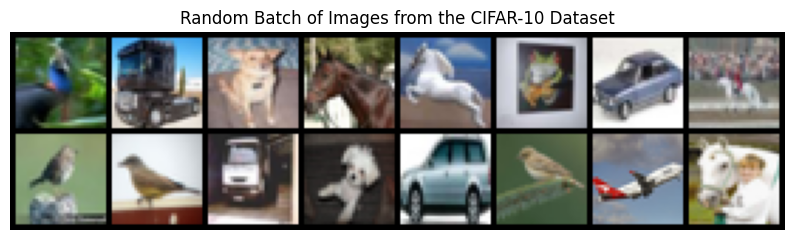

In [5]:
dataiter = iter(CIFAR_10_trainloader)
images, _ = next(dataiter)
imshow(torchvision.utils.make_grid(images[0:16]), "CIFAR-10")

<hr>

## <h1><b> Data Visualisation |<span style="color: #9370DB;"> MINST</span></b></h1>  

<hr>

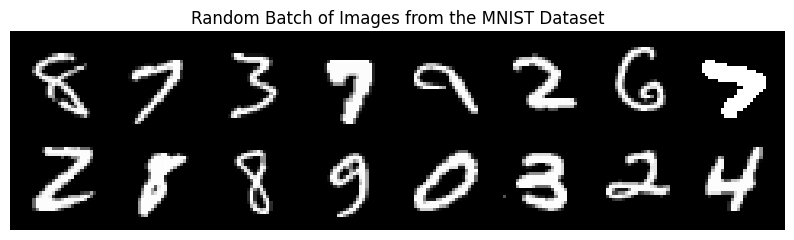

In [6]:
dataiter = iter(MNIST_trainloader)
images, _ = next(dataiter)
imshow(torchvision.utils.make_grid(images[0:16]), "MNIST")

<hr>

## <h1><b> Data Visualisation |<span style="color: #9370DB;"> MINST - Noisy</span></b></h1>  

<hr>

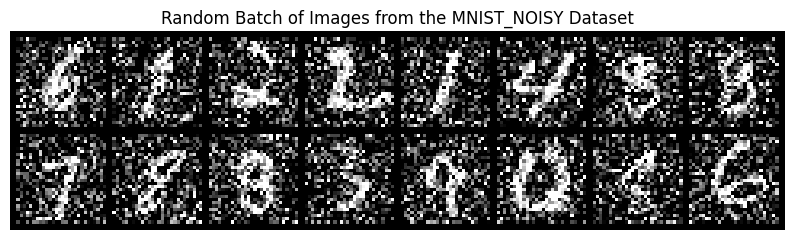

In [7]:
dataiter = iter(MNIST_trainloader_noisy)
images, _ = next(dataiter)
imshow(torchvision.utils.make_grid(images[0:16]), "MNIST_NOISY")

<hr>

## <h1><b> Saving Results |<span style="color: #9370DB;"> JSON File Format</span></b></h1>  

<hr>

In [8]:
# ✏️ ENTER ROLL NUMBER HERE
ROLL_NUMBER = "26100337"

RESULTS_FILE = f"{ROLL_NUMBER}_Overall_Results.json"

Overall_Results = {
    "Task 1": {
        "Train Loss (Last Epoch)": "",
        "Test Loss (Last Epoch)": "",
        "Train Loss (Minimum)": "",
        "Test Loss (Minimum)": ""
    },
    "Task 2": {
        "Train Loss (Last Epoch)": "",
        "Test Loss (Last Epoch)": "",
        "Train Loss (Minimum)": "",
        "Test Loss (Minimum)": ""
    },
    "Task 3": {
        "Train Loss (Last Epoch)": "",
        "Test Loss (Last Epoch)": "",
        "Train Loss (Minimum)": "",
        "Test Loss (Minimum)": ""
    },
    "Task 4": {
        "Train Loss (Last Epoch)": "",
        "Test Loss (Last Epoch)": "",
        "Train Loss (Minimum)": "",
        "Test Loss (Minimum)": ""
    },
    "Task 5": {
        "Train Loss (Last Epoch)": "",
        "Train Accuracy (Last Epoch)": "",
        "Test Loss (Original Dataset)": "",
        "Test Accuracy (Original Dataset)": "",
        "Test Precision (Original Dataset)": "",
        "Test Recall (Original Dataset)": "",
        "Test F1 Score (Original Dataset)": "",
        "Test Loss (LAERecon Dataset)": "",
        "Test Accuracy (LAERecon Dataset)": "",
        "Test Precision (LAERecon Dataset)": "",
        "Test Recall (LAERecon Dataset)": "",
        "Test F1 Score (LAERecon Dataset)": "",
        "Test Loss (CAERecon Dataset)": "",
        "Test Accuracy (CAERecon Dataset)": "",
        "Test Precision (CAERecon Dataset)": "",
        "Test Recall (CAERecon Dataset)": "",
        "Test F1 Score (CAERecon Dataset)": ""
    },
    "Task 6": {
        "Train Loss (Last Epoch)": "",
        "Train Accuracy (Last Epoch)": "",
        "Test Loss (Original Dataset)": "",
        "Test Accuracy (Original Dataset)": "",
        "Test Precision (Original Dataset)": "",
        "Test Recall (Original Dataset)": "",
        "Test F1 Score (Original Dataset)": "",
        "Test Loss (LAEDenoise Dataset)": "",
        "Test Accuracy (LAEDenoise Dataset)": "",
        "Test Precision (LAEDenoise Dataset)": "",
        "Test Recall (LAEDenoise Dataset)": "",
        "Test F1 Score (LAEDenoise Dataset)": "",
        "Test Loss (CAEDenoise Dataset)": "",
        "Test Accuracy (CAEDenoise Dataset)": "",
        "Test Precision (CAEDenoise Dataset)": "",
        "Test Recall (CAEDenoise Dataset)": "",
        "Test F1 Score (CAEDenoise Dataset)": ""
    }
}

with open(RESULTS_FILE, "w") as f:
    json.dump(Overall_Results, f, indent=4)

print("JSON created:", RESULTS_FILE)

JSON created: 26100337_Overall_Results.json


In [9]:
!ls

26100337_Overall_Results.json  data  sample_data


<hr>

## <h1 style="text-align: left;"><b>Task 1: Linear Autoencoder Reconstruction | <span style="color: #9370DB;">CIFAR-10</span></b></h1>

<hr>

### <h2>1. In a Linear Autoencoder (LAE):</h2>

<ul>
    <li>The <b>encoder</b> primarily uses <code>Linear</code> layers to compress the input into a lower-dimensional latent space.</li>
    <li>The <b>decoder</b> utilizes <code>Linear</code> layers to reconstruct the original input from the latent space.</li>
</ul>

<hr>

<h2>2. Fully Connected Layers in a Linear Autoencoder</h2>

<table border="1" cellpadding="10" cellspacing="0" width="100%">
    <tr style="background-color:rgb(60, 60, 60);">
        <th style="text-align: left;">Layer</th>
        <th style="text-align: left;">Function</th>
    </tr>
    <tr>
        <td><b>Linear</b></td>
        <td>Applies a fully connected transformation to project the input into a lower-dimensional space (encoding) or reconstruct it back (decoding).</td>
    </tr>
</table>

<p>You can read the PyTorch documentation as well for more information!</p>

<hr>

<h2>3. Understanding Linear Layers</h2>

<h3>Linear Layer</h3>
<p>A <b>Linear Layer</b> applies a fully connected transformation, mapping an input vector to an output vector using weights and biases.</p>
<p><b>Syntax:</b></p>
<pre style="background-color:rgb(60, 60, 60); padding: 10px; border-radius: 5px;">
nn.Linear(in_features, out_features)
</pre>

<ul>
    <li><b>in_features:</b> Number of input features (e.g., flattened image pixels).</li>
    <li><b>out_features:</b> Number of output features (e.g., latent space dimension).</li>
</ul>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Linear Autoencoder</span></h1>

<hr>

In [10]:
class LinearAutoencoderRecon(nn.Module):
    def __init__(self):
        super(LinearAutoencoderRecon, self).__init__()
        # ===================== YOUR CODE HERE ======================
        # input = cifar-10 images (3, 32, 32) flattened to 3072 vector
        # encoder = 3072 to 1024 to 256 to 64 (latent space)
        # decoder = 64 to 256 to 1024 to 3072 vector reshaped to (3, 32, 32)
        self.encoder = nn.Sequential(
            nn.Linear(3*32*32, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        self.decoder= nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid() #[0,1] output
        )
        # =========================================================== 
        #raise NotImplementedError
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        x = x.view(x.size(0),-1) #flatten input
        z= self.encoder(x)
        out= self.decoder(z)
        out = out.view(x.size(0), 3, 32, 32) #reshape to image size 
        return out
        # =========================================================== 
        #raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">LAERecon</span></h1>

<hr>

### <p><strong>Overview:</strong><br>
The <code>LAERecon</code> is a class designed to facilitate the training, evaluation, and visualization of a <strong>Linear Autoencoder (LAE)</strong> model. It manages the training loop, computes losses, performs evaluations, and visualizes reconstructions to monitor model performance. The class also includes methods for saving and loading the model.</p>

---

<h3>Constructor (<code>__init__</code>):</h3>
<p>The constructor initializes key components:</p>
<ul>
  <li><code>model (nn.Module)</code>: The Linear Autoencoder model.</li>
  <li><code>train_loader (DataLoader)</code>: The training dataset loader.</li>
  <li><code>test_loader (DataLoader)</code>: The test dataset loader.</li>
  <li><code>lr (float)</code>: Learning rate for the optimizer (default <code>0.001</code>).</li>
  <li><code>num_epochs (int)</code>: Number of training epochs (default <code>20</code>).</li>
  <li><code>device (str or None)</code>: Device for computation (auto-detects if set to <code>None</code>).</li>
  <li><code>imshow_func (function or None)</code>: Optional function for visualizing reconstructions.</li>
</ul>

---

<h3>Methods:</h3>

<h4>1. Training (<code>train</code>)</h4>
<p><strong>Purpose:</strong> Trains the autoencoder over multiple epochs.</p>
<p><strong>Workflow:</strong> Iterates through training batches, performs a forward pass, computes loss, and updates weights using backpropagation. After each epoch, it evaluates the model and prints the training loss.</p>

<h4>2. Evaluation (<code>evaluate</code>)</h4>
<p><strong>Purpose:</strong> Evaluates the trained model's performance on the test dataset.</p>
<p><strong>Workflow:</strong> The model is set to evaluation mode, and test loss is calculated by comparing reconstructed outputs to the original images.</p>

<h4>3. Model Saving (<code>save_model</code>)</h4>
<p><strong>Purpose:</strong> Saves the trained model to a specified file path.</p>
<p><strong>Outputs:</strong> Prints a confirmation message upon saving.</p>

<h4>4. Model Loading (<code>load_model</code>)</h4>
<p><strong>Purpose:</strong> Loads a saved model from a specified file path.</p>
<p><strong>Outputs:</strong> Prints a confirmation message upon loading.</p>

<h4>5. Plotting Results (<code>plot_results</code>)</h4>
<p><strong>Purpose:</strong> Plots training and test losses over the epochs.</p>

<h4>6. Visualization of Reconstructions (<code>visualize_reconstructions</code>)</h4>
<p><strong>Purpose:</strong> Displays original and reconstructed images for model performance assessment.</p>

---

<h3>Example Usage:</h3>

```python
    # Instantiate the LAERecon class
    trainer = LAERecon(model, train_loader, test_loader, lr=0.001, num_epochs=20, device='cuda')

    # Start training
    trainer.train()

    # Plot training and test loss
    trainer.plot_results()

    # Visualize reconstructions
    trainer.visualize_reconstructions(num_images=5)
```

---

<h3>Summary:</h3>
<ul>
  <li>Handles training, evaluation, and visualization of a Linear Autoencoder.</li>
  <li>Supports model saving and loading.</li>
  <li>Provides loss tracking and reconstruction visualization.</li>
</ul>

<h3>Notes:</h3>
<ul>
  <li>Allows custom image visualization via <code>imshow_func</code>.</li>
  <li>Keeps track of loss trends for analysis.</li>
</ul>

In [11]:
class LAERecon:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Linear Autoencoder Trainer.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (reconstructions).
        """
        self.name = "Linear Autoencoder (Reconstruction)"
        # ===================== YOUR CODE HERE =====================
        self.model=model
        self.train_loader=train_loader
        self.test_loader=test_loader
        self.lr=lr
        self.num_epochs=num_epochs
        self.imshow_func=imshow_func
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device=torch.device(device)
        self.model.to(self.device)
        self.criterion=nn.MSELoss()
        self.optimizer=torch.optim.Adam(self.model.parameters(),lr=self.lr)
        self.train_losses=[]
        self.test_losses=[]   
        # ===========================================================

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss=0.0
            for images, _ in self.train_loader:
                images = images.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, images)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * images.size(0)

            epoch_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_loss)
            self.evaluate(epoch, train=True)

            print(f"Epoch [{epoch+1}/{self.num_epochs}]  Train Loss: {epoch_loss:.6f}  Test Loss: {self.test_losses[-1]:.6f}")
        # =========================================================== 
        #raise NotImplementedError

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for images, _ in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, images)
                running_loss += loss.item() * images.size(0)

        test_loss = running_loss / len(self.test_loader.dataset)
        self.test_losses.append(test_loss)
        # =========================================================== 
        #raise NotImplementedError

    def save_model(self, path="/models/LAE_RECON.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="/models/LAE_RECON.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE ======================
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, len(self.train_losses)+1), self.train_losses, label="Train Loss", marker='o')
        plt.plot(range(1, len(self.test_losses)+1), self.test_losses, label="Test Loss", marker='s')
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"{self.name} — Loss Curves")
        plt.legend()
        plt.tight_layout()
        plt.show()
        # ===========================================================
        #raise NotImplementedError

    def visualize_reconstructions(self, num_images=5):
        """ 
        Visualizes the original and reconstructed images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        images, _ = next(iter(self.test_loader))
        images = images[:num_images].to(self.device)

        with torch.no_grad():
            reconstructed = self.model(images)

        images = images.cpu()
        reconstructed = reconstructed.cpu()

        fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
        for i in range(num_images):
            img = images[i]
            rec = reconstructed[i]

            if self.imshow_func:
                axes[0, i].imshow(self.imshow_func(img))
                axes[1, i].imshow(self.imshow_func(rec))
            else:
                # Handle both grayscale (1, H, W) and RGB (3, H, W)
                img_np = img.permute(1, 2, 0).numpy().clip(0, 1)
                rec_np = rec.permute(1, 2, 0).numpy().clip(0, 1)
                if img_np.shape[2] == 1:
                    axes[0, i].imshow(img_np.squeeze(), cmap='gray')
                    axes[1, i].imshow(rec_np.squeeze(), cmap='gray')
                else:
                    axes[0, i].imshow(img_np)
                    axes[1, i].imshow(rec_np)

            axes[0, i].axis('off')
            axes[1, i].axis('off')

        axes[0, 0].set_ylabel("Original", fontsize=12)
        axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
        plt.suptitle(f"{self.name} — Reconstructions")
        plt.tight_layout()
        plt.show()
        # ===========================================================
        #raise NotImplementedError
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        all_reconstructed = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                all_reconstructed.append(outputs.cpu())
                all_labels.append(labels)

        all_reconstructed = torch.cat(all_reconstructed, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        recon_dataset = torch.utils.data.TensorDataset(all_reconstructed, all_labels)
        recon_loader = torch.utils.data.DataLoader(recon_dataset, batch_size=self.test_loader.batch_size, shuffle=False)
        return recon_loader
        # =========================================================== 
        #raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [12]:
LAE_RECON_Model = LinearAutoencoderRecon()
LAE_RECON_Trainer = LAERecon(
    model=LAE_RECON_Model,
    train_loader=CIFAR_10_trainloader,
    test_loader=CIFAR_10_testloader,
    lr=LEARNING_RATE,
    num_epochs=EPOCHS,
    device=device
)

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [13]:
# ===================== YOUR CODE HERE ======================
LAE_RECON_Trainer.train()
# ===========================================================
#raise NotImplementedError

Epoch [1/10]  Train Loss: 0.030646  Test Loss: 0.023993
Epoch [2/10]  Train Loss: 0.022122  Test Loss: 0.020747
Epoch [3/10]  Train Loss: 0.019238  Test Loss: 0.018587
Epoch [4/10]  Train Loss: 0.017165  Test Loss: 0.016446
Epoch [5/10]  Train Loss: 0.016264  Test Loss: 0.016003
Epoch [6/10]  Train Loss: 0.015376  Test Loss: 0.015185
Epoch [7/10]  Train Loss: 0.014734  Test Loss: 0.014593
Epoch [8/10]  Train Loss: 0.014302  Test Loss: 0.014008
Epoch [9/10]  Train Loss: 0.013767  Test Loss: 0.013744
Epoch [10/10]  Train Loss: 0.013323  Test Loss: 0.013320


<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

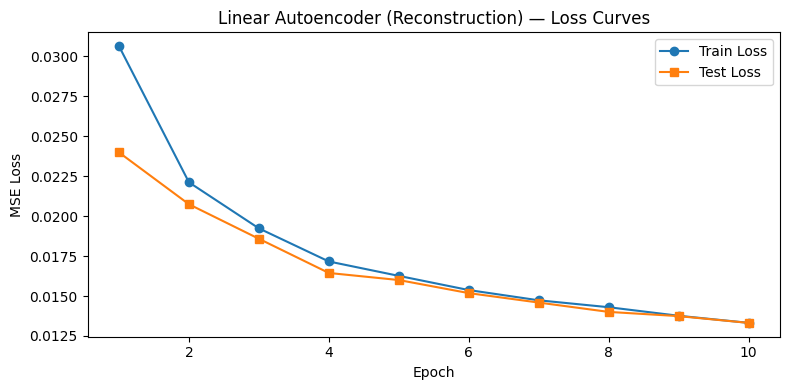

In [14]:
# ===================== YOUR CODE HERE ======================
LAE_RECON_Trainer.plot_results()
# ===========================================================
#raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

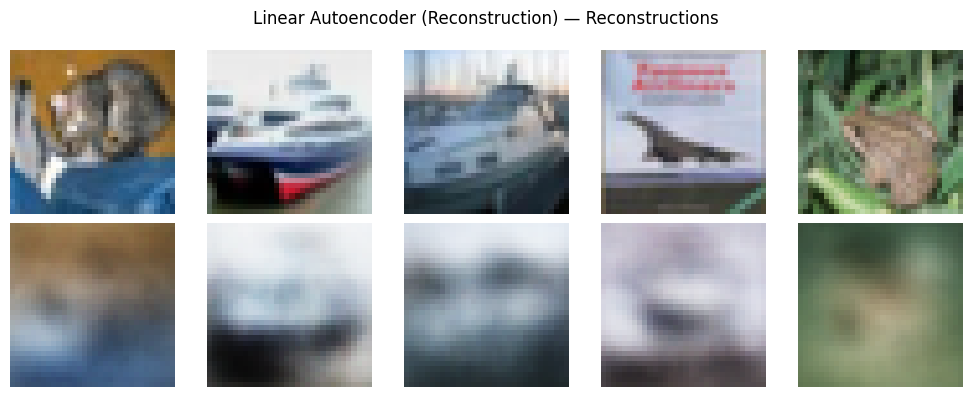

In [15]:
# ===================== YOUR CODE HERE ======================
LAE_RECON_Trainer.visualize_reconstructions(num_images=5)
# ===========================================================
#raise NotImplementedError
# Update Overall_Results dictionary with actual values after training and evaluation
Overall_Results["Task 1"] = {
    "Train Loss (Last Epoch)": LAE_RECON_Trainer.train_losses[-1],
    "Test Loss (Last Epoch)": LAE_RECON_Trainer.test_losses[-1],
    "Train Loss (Minimum)": min(LAE_RECON_Trainer.train_losses),
    "Test Loss (Minimum)": min(LAE_RECON_Trainer.test_losses),
}

<hr>

### <h1 style="text-align: left;">Task 1 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 2: Convolutional Autoencoder Reconstruction | <span style="color: #9370DB;">CIFAR-10</span></b></h1>

<hr>


### <h2>1. In a Convolutional Autoencoder (CAE):</h2>

<ul>
    <li>The <b>encoder</b> primarily uses <code>Conv2d</code> and <code>MaxPool2d</code> layers for feature extraction and dimensionality reduction.</li>
    <li>The <b>decoder</b> utilizes <code>ConvTranspose2d</code> to upsample and reconstruct the original image.</li>
</ul>

<hr>

<h2>2. Convolutional Layers in a Convolutional Autoencoder</h2>

<table border="1" cellpadding="10" cellspacing="0" width="100%">
    <tr style="background-color:rgb(60, 60, 60);">
        <th style="text-align: left;">Layer</th>
        <th style="text-align: left;">Function</th>
    </tr>
    <tr>
        <td><b>Conv2d</b></td>
        <td>Extracts spatial features from the input image by applying filters.</td>
    </tr>
    <tr>
        <td><b>MaxPool2d</b></td>
        <td>Downsamples feature maps to reduce spatial dimensions while preserving key information.</td>
    </tr>
    <tr>
        <td><b>ConvTranspose2d</b></td>
        <td>Upsamples the compressed feature maps to reconstruct the original image.</td>
    </tr>
</table>

<p>You can read the PyTorch documentation aswell for more information!</p>

<hr>

<h2>3. Understanding Conv2d and ConvTranspose2d</h2>

<h3>Conv2d</h3>
<p>A <b>2D Convolutional Layer</b> applies filters (kernels) to the input image to extract spatial patterns such as edges and textures.</p>
<p><b>Syntax:</b></p>
<pre style="background-color:rgb(60, 60, 60); padding: 10px; border-radius: 5px;">
nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
</pre>

<ul>
    <li><b>in_channels:</b> Number of input channels (e.g., 3 for RGB images).</li>
    <li><b>out_channels:</b> Number of filters applied to extract features.</li>
    <li><b>kernel_size:</b> Size of the filter (e.g., 3×3).</li>
    <li><b>stride:</b> Step size for moving the filter across the image.</li>
    <li><b>padding:</b> Adds zero-padding to maintain spatial dimensions.</li>
</ul>

<h3>ConvTranspose2d</h3>
<p>The <b>ConvTranspose2d</b> layer performs the reverse operation of <b>Conv2d</b>, increasing the spatial dimensions of the feature maps.</p>
<p><b>Syntax:</b></p>
<pre style="background-color:rgb(60, 60, 60); padding: 10px; border-radius: 5px;">
nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding)
</pre>

<ul>
    <li><b>in_channels:</b> Number of channels from the latent space.</li>
    <li><b>out_channels:</b> Number of filters used to reconstruct the image.</li>
    <li><b>kernel_size:</b> Size of the upsampling filter.</li>
    <li><b>stride:</b> Determines how much the feature maps expand.</li>
    <li><b>padding:</b> Adjusts spatial dimensions for accurate reconstruction.</li>
</ul>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Convolutional AutoEncoder</span></h1>

<hr>

In [16]:
class ConvolutionalAutoencoderRecon(nn.Module):
    def __init__(self):
        super(ConvolutionalAutoencoderRecon, self).__init__()
        # ===================== YOUR CODE HERE =====================
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 32, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 64, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (B, 128, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (B, 128, 4, 4)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # (B, 64, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),   # (B, 32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),    # (B, 3, 32, 32)
            nn.Sigmoid()
        )
        # ===========================================================
        
    def forward(self, x):
        # ===================== YOUR CODE HERE =====================
        x = self.encoder(x)
        x = self.decoder(x)
        # ===========================================================
        return x

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">CAERecon</span></h1>

<hr>

### <p><strong>Overview:</strong><br>
The <code>CAERecon</code> is a class designed to facilitate the training, evaluation, and visualization of a <strong>Convolutional Autoencoder (CAE)</strong> model. It handles the training loop, computes losses, performs model evaluations after each epoch, and enables visualization of reconstructions to monitor model progress. The class also provides methods to save and load the model at any point.</p>

---

<h3>Constructor (<code>__init__</code>):</h3>
<p>The constructor initializes key components for training, evaluation, and visualization:</p>
<ul>
  <li><code>model (nn.Module)</code>: The Autoencoder model to be trained.</li>
  <li><code>train_loader (DataLoader)</code>: The training dataset loader.</li>
  <li><code>test_loader (DataLoader)</code>: The test dataset loader.</li>
  <li><code>lr (float)</code>: Learning rate for the optimizer (default is <code>0.001</code>).</li>
  <li><code>num_epochs (int)</code>: Number of epochs for training (default is <code>20</code>).</li>
  <li><code>device (str or None)</code>: Specifies the device for computation (e.g., 'cuda', 'mps', 'cpu'). It auto-detects if set to <code>None</code>.</li>
  <li><code>imshow_func (function or None)</code>: An optional function for visualizing images (reconstructed outputs from the model). This allows for custom image visualization logic, if needed.</li>
</ul>
<p>The constructor sets up the model, loss function (<code>MSELoss</code>), optimizer (<code>Adam</code>), and prepares lists for storing training and test losses. It also prints a summary of the model.</p>

---

<h3>Methods:</h3>

<h4>1. Training (<code>train</code>)</h4>
<p><strong>Purpose:</strong> Trains the autoencoder model over a specified number of epochs.</p>
<p><strong>Workflow:</strong> Iterates over training data, performing a forward pass, calculating loss, and updating model weights using backpropagation. After every epoch, the method prints the training loss and calls the <code>evaluate</code> method to assess the model on the test dataset.</p>
<p><strong>Outputs:</strong> Prints the average training loss at the end of each epoch.</p>

<h4>2. Evaluation (<code>evaluate</code>)</h4>
<p><strong>Purpose:</strong> Evaluates the trained model's performance on the test dataset after each epoch.</p>
<p><strong>Workflow:</strong> The model is set to evaluation mode (<code>eval</code>), and predictions are made on the test set. The <strong>test loss</strong> is computed by comparing the model's outputs with the ground truth.</p>
<p><strong>Outputs:</strong> Prints the test loss for the current epoch.</p>

<h4>3. Model Saving (<code>save_model</code>)</h4>
<p><strong>Purpose:</strong> Saves the trained model to a file.</p>
<p><strong>Path:</strong> The model is saved to the provided path (default is <code>/models/cae_model.pth</code>).</p>
<p><strong>Outputs:</strong> Prints a message confirming the model has been saved to the specified path.</p>

<h4>4. Model Loading (<code>load_model</code>)</h4>
<p><strong>Purpose:</strong> Loads a pre-trained model from a file.</p>
<p><strong>Path:</strong> Loads the model from the specified path (default is <code>/models/cae_model.pth</code>).</p>
<p><strong>Outputs:</strong> Prints a message confirming the model has been loaded from the specified path.</p>

<h4>5. Plotting Results (<code>plot_results</code>)</h4>
<p><strong>Purpose:</strong> Plots the training and test losses over the course of training.</p>
<p><strong>Workflow:</strong> After training, this method visualizes the losses for both training and test sets over all epochs.</p>
<p><strong>Outputs:</strong> Displays a plot with two lines: one for <strong>training loss</strong> and one for <strong>test loss</strong>, enabling a comparison of performance.</p>

<h4>6. Visualization of Reconstructions (<code>visualize_reconstructions</code>)</h4>
<p><strong>Purpose:</strong> Visualizes the <strong>original images</strong> alongside their <strong>reconstructed outputs</strong> from the trained model.</p>
<p><strong>Workflow:</strong> The model is set to evaluation mode (<code>eval</code>). A batch of test images is passed through the model to obtain reconstructions. A few images (specified by <code>num_images</code>) are displayed, where the first image in each pair is the ground truth and the second is the reconstruction.</p>
<p><strong>Outputs:</strong> Displays side-by-side visualizations of original and reconstructed images for comparison.</p>

---

<h3>Example Usage:</h3>

```python
# Instantiate the CAERecon class
trainer = CAERecon(model, train_loader, test_loader, lr=0.001, num_epochs=20, device='cuda')

# Start training
trainer.train()

# After training, plot the training and test losses
trainer.plot_results()

# Visualize the reconstructions from the test set
trainer.visualize_reconstructions(num_images=5)
```

---

<h3>Summary:</h3>
<p>The <code>CAERecon</code> class provides an end-to-end solution for training a <strong>Convolutional Autoencoder (CAE)</strong> model. It includes methods for:</p>
<ul>
  <li>Training and loss calculation</li>
  <li>Periodic evaluation and printing of test losses</li>
  <li>Visualizing reconstructed images alongside ground truth</li>
  <li>Saving and loading model weights</li>
</ul>
<p>This structure helps you monitor the model's progress at each epoch, assess performance, and visualize the model's reconstructions in a streamlined manner.</p>

---

<h3>Notes:</h3>
<ul>
  <li>The class is designed to be flexible and can accept a custom image visualization function (<code>imshow_func</code>) for visualizing the model's reconstructions.</li>
  <li>Loss values are tracked during training and evaluation for both training and test sets, enabling meaningful analysis of model performance over time.</li>
</ul>

In [17]:
class CAERecon:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Convolutional Autoencoder Trainer.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (reconstructions).
        """
        self.name = "Convolutional Autoencoder (Reconstruction)"
        # ===================== YOUR CODE HERE =====================
        self.model = model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.lr = lr
        self.num_epochs = num_epochs
        self.imshow_func = imshow_func

        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.model.to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.train_losses = []
        self.test_losses = []

        print(self.model)
        # ===========================================================

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0

            for images, _ in self.train_loader:
                images = images.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, images)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * images.size(0)

            epoch_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_loss)
            self.evaluate(epoch, train=True)

            print(f"Epoch [{epoch+1}/{self.num_epochs}]  Train Loss: {epoch_loss:.6f}  Test Loss: {self.test_losses[-1]:.6f}")

        # =========================================================== 
        #raise NotImplementedError

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        running_loss = 0.0

        with torch.no_grad():
            for images, _ in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, images)
                running_loss += loss.item() * images.size(0)

        test_loss = running_loss / len(self.test_loader.dataset)
        self.test_losses.append(test_loss)

        # =========================================================== 
        #raise NotImplementedError

    def save_model(self, path="/models/CAE_RECON.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="/models/CAE_RECON.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE ======================
        plt.plot(range(1, len(self.train_losses)+1), self.train_losses, label="Train Loss", marker='o')
        plt.plot(range(1, len(self.test_losses)+1), self.test_losses, label="Test Loss", marker='s')
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"{self.name} — Loss Curves")
        plt.legend()
        plt.tight_layout()
        plt.show()
        # ===========================================================
        #raise NotImplementedError

    def visualize_reconstructions(self, num_images=5):
        """ 
        Visualizes the original and reconstructed images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        images, _ = next(iter(self.test_loader))
        images = images[:num_images].to(self.device)

        with torch.no_grad():
            reconstructed = self.model(images)

        images = images.cpu()
        reconstructed = reconstructed.cpu()

        fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
        for i in range(num_images):
            img = images[i]
            rec = reconstructed[i]

            if self.imshow_func:
                axes[0, i].imshow(self.imshow_func(img))
                axes[1, i].imshow(self.imshow_func(rec))
            else:
                img_np = img.permute(1, 2, 0).numpy().clip(0, 1)
                rec_np = rec.permute(1, 2, 0).numpy().clip(0, 1)
                if img_np.shape[2] == 1:
                    axes[0, i].imshow(img_np.squeeze(), cmap='gray')
                    axes[1, i].imshow(rec_np.squeeze(), cmap='gray')
                else:
                    axes[0, i].imshow(img_np)
                    axes[1, i].imshow(rec_np)

            axes[0, i].axis('off')
            axes[1, i].axis('off')

        axes[0, 0].set_ylabel("Original", fontsize=12)
        axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
        plt.suptitle(f"{self.name} — Reconstructions")
        plt.tight_layout()
        plt.show()
        # ===========================================================
        #raise NotImplementedError
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        all_reconstructed = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                all_reconstructed.append(outputs.cpu())
                all_labels.append(labels)

        all_reconstructed = torch.cat(all_reconstructed, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        recon_dataset = torch.utils.data.TensorDataset(all_reconstructed, all_labels)
        recon_loader = torch.utils.data.DataLoader(recon_dataset, batch_size=self.test_loader.batch_size, shuffle=False)
        return recon_loader
        # =========================================================== 
        #raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [18]:
CAE_RECON_Model = ConvolutionalAutoencoderRecon()
CAE_RECON_Trainer = CAERecon(
    model=CAE_RECON_Model,
    train_loader=CIFAR_10_trainloader,
    test_loader=CIFAR_10_testloader,
    lr=LEARNING_RATE,
    num_epochs=EPOCHS,
    device=None
)

ConvolutionalAutoencoderRecon(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)


<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [19]:
# ===================== YOUR CODE HERE ======================
CAE_RECON_Trainer.train()
# ===========================================================
#raise NotImplementedError

Epoch [1/10]  Train Loss: 0.019843  Test Loss: 0.014237
Epoch [2/10]  Train Loss: 0.011029  Test Loss: 0.009983
Epoch [3/10]  Train Loss: 0.009447  Test Loss: 0.009396
Epoch [4/10]  Train Loss: 0.008502  Test Loss: 0.008062
Epoch [5/10]  Train Loss: 0.007643  Test Loss: 0.007422
Epoch [6/10]  Train Loss: 0.007120  Test Loss: 0.006936
Epoch [7/10]  Train Loss: 0.006797  Test Loss: 0.006615
Epoch [8/10]  Train Loss: 0.006546  Test Loss: 0.006597
Epoch [9/10]  Train Loss: 0.006339  Test Loss: 0.006287
Epoch [10/10]  Train Loss: 0.006170  Test Loss: 0.006201


<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

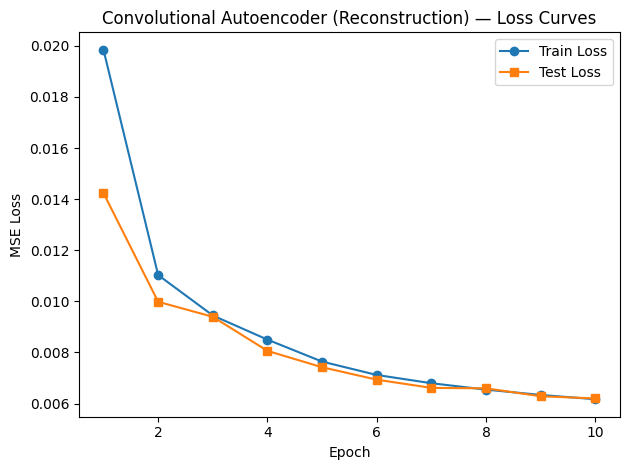

In [20]:
# ===================== YOUR CODE HERE ======================
CAE_RECON_Trainer.plot_results()
# ===========================================================
#raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

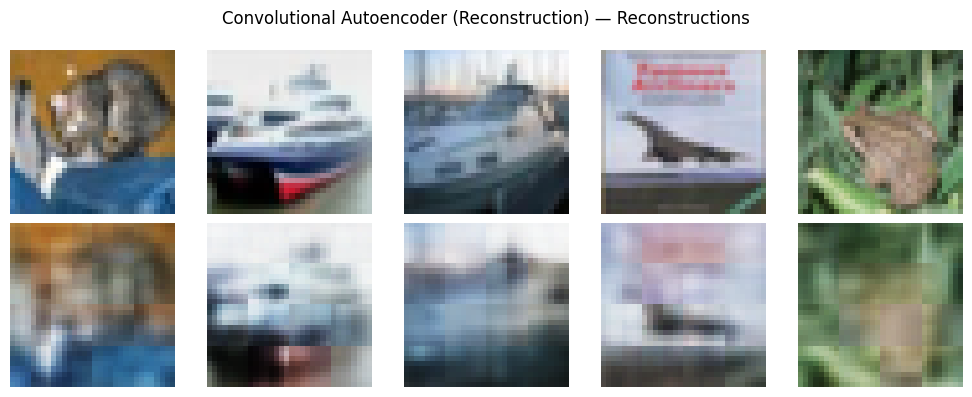

In [21]:
# ===================== YOUR CODE HERE ======================
CAE_RECON_Trainer.visualize_reconstructions(num_images=5)
# ===========================================================
#raise NotImplementedError
# Update Overall_Results dictionary with actual values after training and evaluation
Overall_Results["Task 2"] = {
    "Train Loss (Last Epoch)": CAE_RECON_Trainer.train_losses[-1],
    "Test Loss (Last Epoch)":  CAE_RECON_Trainer.test_losses[-1],
    "Train Loss (Minimum)":    min(CAE_RECON_Trainer.train_losses),
    "Test Loss (Minimum)":     min(CAE_RECON_Trainer.test_losses),
}

<hr>

## <h1 style="text-align: left;"><b>Task 3: Linear Autoencoder Denoising | <span style="color: #9370DB;">MNIST</span></b></h1>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Linear Autoencoder</span></h1>

<hr>

In [22]:
class LinearAutoencoderDenoise(nn.Module):
    def __init__(self):
        super(LinearAutoencoderDenoise, self).__init__()
        # ===================== YOUR CODE HERE =====================
        
        self.encoder = nn.Sequential(
            nn.Linear(784, 512), #1X28X28=784
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )
        
        # ===========================================================
        
    def forward(self, x):
        # ===================== YOUR CODE HERE =====================
        x = x.view(x.size(0), -1)          # flatten: (B, 1, 28, 28) → (B, 784)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(x.size(0), 1, 28, 28)   # reshape back
        # ===========================================================
        return x

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">LAEDenoise</span></h1>

<hr>

In [23]:
class LAEDenoise:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Linear Autoencoder Trainer for Denoising.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (denoised reconstructions).
        """
        self.name = "Linear Autoencoder (Denoising)"
        # ===================== YOUR CODE HERE =====================
        self.model = model
        self.train_loader = train_loader  # noisy loader
        self.test_loader = test_loader    # noisy loader
        self.lr = lr
        self.num_epochs = num_epochs
        self.imshow_func = imshow_func

        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.model.to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.train_losses = []
        self.test_losses = []

        self.clean_train_loader = MNIST_trainloader
        self.clean_test_loader = MNIST_testloader
        # ===========================================================

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0

            for (noisy_imgs, _), (clean_imgs, _) in zip(self.train_loader, self.clean_train_loader):
                noisy_imgs = noisy_imgs.to(self.device)
                clean_imgs = clean_imgs.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(noisy_imgs)
                loss = self.criterion(outputs, clean_imgs)  # denoise: compare to clean
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * noisy_imgs.size(0)

            epoch_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_loss)
            self.evaluate(epoch, train=True)

            print(f"Epoch [{epoch+1}/{self.num_epochs}]  Train Loss: {epoch_loss:.6f}  Test Loss: {self.test_losses[-1]:.6f}")
        # =========================================================== 
        #raise NotImplementedError

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        running_loss = 0.0

        with torch.no_grad():
            for (noisy_imgs, _), (clean_imgs, _) in zip(self.test_loader, self.clean_test_loader):
                noisy_imgs = noisy_imgs.to(self.device)
                clean_imgs = clean_imgs.to(self.device)
                outputs = self.model(noisy_imgs)
                loss = self.criterion(outputs, clean_imgs)
                running_loss += loss.item() * noisy_imgs.size(0)

        test_loss = running_loss / len(self.test_loader.dataset)
        self.test_losses.append(test_loss)

        # =========================================================== 
        #raise NotImplementedError

    def save_model(self, path="/models/LAE_DENOISE.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="/models/LAE_DENOISE.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE =====================
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, len(self.train_losses)+1), self.train_losses, label="Train Loss", marker='o')
        plt.plot(range(1, len(self.test_losses)+1), self.test_losses, label="Test Loss", marker='s')
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"{self.name} — Loss Curves")
        plt.legend()
        plt.tight_layout()
        plt.show()
        # ===========================================================

    def visualize_denoising(self, num_images=5):
        """ 
        Visualizes the original and denoised images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE =====================
        self.model.eval()
        noisy_imgs, _ = next(iter(self.test_loader))
        clean_imgs, _ = next(iter(self.clean_test_loader))

        noisy_imgs = noisy_imgs[:num_images].to(self.device)
        clean_imgs = clean_imgs[:num_images]

        with torch.no_grad():
            denoised = self.model(noisy_imgs).cpu()

        noisy_imgs = noisy_imgs.cpu()

        fig, axes = plt.subplots(3, num_images, figsize=(num_images * 2, 6))
        row_labels = ["Noisy", "Denoised", "Clean"]

        for i in range(num_images):
            for row, img in enumerate([noisy_imgs[i], denoised[i], clean_imgs[i]]):
                img_np = img.permute(1, 2, 0).numpy().clip(0, 1).squeeze()
                axes[row, i].imshow(img_np, cmap='gray')
                axes[row, i].axis('off')

        for row, label in enumerate(row_labels):
            axes[row, 0].set_ylabel(label, fontsize=12)

        plt.suptitle(f"{self.name} — Denoising Results")
        plt.tight_layout()
        plt.show()
        # ===========================================================
        #raise NotImplementedError
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        all_denoised = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                all_denoised.append(outputs.cpu())
                all_labels.append(labels)

        all_denoised = torch.cat(all_denoised, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        denoised_dataset = torch.utils.data.TensorDataset(all_denoised, all_labels)
        denoised_loader = torch.utils.data.DataLoader(denoised_dataset, batch_size=self.test_loader.batch_size, shuffle=False)
        return denoised_loader
        # =========================================================== 
        #raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [24]:
LAE_DENOISE_Model = LinearAutoencoderDenoise()
LAE_DENOISE_Trainer = LAEDenoise(
    model=LAE_DENOISE_Model,
    train_loader=MNIST_trainloader_noisy,
    test_loader=MNIST_testloader_noisy,
    lr=LEARNING_RATE,
    num_epochs=EPOCHS,
    device=None
)

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [25]:
# ===================== YOUR CODE HERE ======================
LAE_DENOISE_Trainer.train()
# ===========================================================
#raise NotImplementedError

Epoch [1/10]  Train Loss: 0.071028  Test Loss: 0.067539
Epoch [2/10]  Train Loss: 0.067367  Test Loss: 0.067527
Epoch [3/10]  Train Loss: 0.067323  Test Loss: 0.067601
Epoch [4/10]  Train Loss: 0.067324  Test Loss: 0.067524
Epoch [5/10]  Train Loss: 0.067307  Test Loss: 0.067498
Epoch [6/10]  Train Loss: 0.067301  Test Loss: 0.067470
Epoch [7/10]  Train Loss: 0.067295  Test Loss: 0.067438
Epoch [8/10]  Train Loss: 0.067301  Test Loss: 0.067547
Epoch [9/10]  Train Loss: 0.067297  Test Loss: 0.067492
Epoch [10/10]  Train Loss: 0.067297  Test Loss: 0.067514


<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

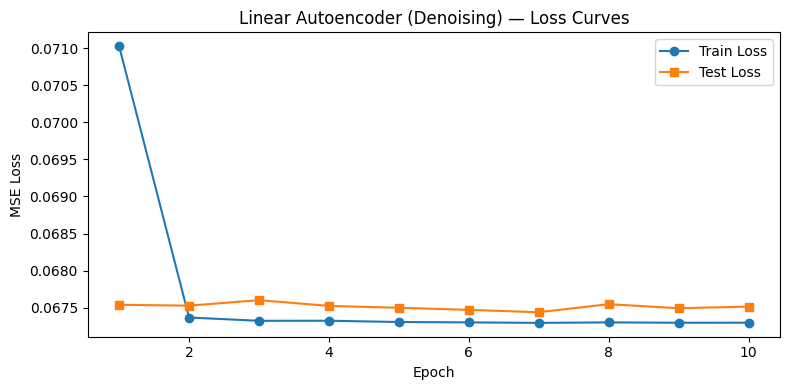

In [26]:
# ===================== YOUR CODE HERE ======================
LAE_DENOISE_Trainer.plot_results()
# ===========================================================
#raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

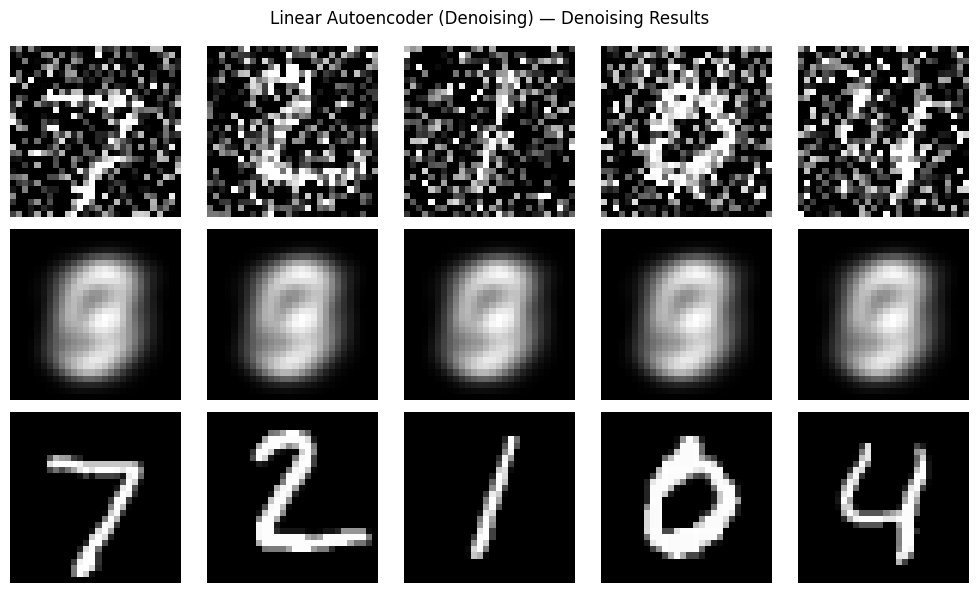

In [27]:
# ===================== YOUR CODE HERE ======================
LAE_DENOISE_Trainer.visualize_denoising(num_images=5)
# ===========================================================
#raise NotImplementedError
# Update Overall_Results dictionary with actual values after training and evaluation
Overall_Results["Task 3"] = {
    "Train Loss (Last Epoch)": LAE_DENOISE_Trainer.train_losses[-1],
    "Test Loss (Last Epoch)":  LAE_DENOISE_Trainer.test_losses[-1],
    "Train Loss (Minimum)":    min(LAE_DENOISE_Trainer.train_losses),
    "Test Loss (Minimum)":     min(LAE_DENOISE_Trainer.test_losses),
}

<hr>

### <h1 style="text-align: left;">Task 3 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 4: Convolutional Autoencoder Denoising | <span style="color: #9370DB;">MNIST</span></b></h1>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Convolutional AutoEncoder</span></h1>

<hr>

In [28]:
class ConvolutionalAutoencoderDenoise(nn.Module):
    def __init__(self):
        super(ConvolutionalAutoencoderDenoise, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (B, 32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (B, 64, 7, 7)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # (B, 32, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),   # (B, 1, 28, 28)
            nn.Sigmoid()
        )
        # =========================================================== 
        #raise NotImplementedError
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        x = self.encoder(x)
        x = self.decoder(x)
        return x
        # =========================================================== 
        #raise NotImplementedError

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">CAEDenoise</span></h1>

<hr>

In [29]:
class CAEDenoise:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Convolutional Autoencoder Trainer for Denoising.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (denoised reconstructions).
        """
        self.name = "Convolutional Autoencoder (Denoising)"
        # ===================== YOUR CODE HERE ======================
        self.model = model
        self.train_loader = train_loader  # noisy loader
        self.test_loader = test_loader    # noisy loader
        self.lr = lr
        self.num_epochs = num_epochs
        self.imshow_func = imshow_func

        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.model.to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.train_losses = []
        self.test_losses = []

        self.clean_train_loader = MNIST_trainloader
        self.clean_test_loader = MNIST_testloader
        # =========================================================== 
        #raise NotImplementedError

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0

            for (noisy_imgs, _), (clean_imgs, _) in zip(self.train_loader, self.clean_train_loader):
                noisy_imgs = noisy_imgs.to(self.device)
                clean_imgs = clean_imgs.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(noisy_imgs)
                loss = self.criterion(outputs, clean_imgs)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * noisy_imgs.size(0)

            epoch_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_loss)
            self.evaluate(epoch, train=True)

            print(f"Epoch [{epoch+1}/{self.num_epochs}]  Train Loss: {epoch_loss:.6f}  Test Loss: {self.test_losses[-1]:.6f}")

        # =========================================================== 
        #raise NotImplementedError

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        running_loss = 0.0

        with torch.no_grad():
            for (noisy_imgs, _), (clean_imgs, _) in zip(self.test_loader, self.clean_test_loader):
                noisy_imgs = noisy_imgs.to(self.device)
                clean_imgs = clean_imgs.to(self.device)
                outputs = self.model(noisy_imgs)
                loss = self.criterion(outputs, clean_imgs)
                running_loss += loss.item() * noisy_imgs.size(0)

        test_loss = running_loss / len(self.test_loader.dataset)
        self.test_losses.append(test_loss)

    def save_model(self, path="/models/CAE_DENOISE.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="/models/CAE_DENOISE.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE =====================
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, len(self.train_losses)+1), self.train_losses, label="Train Loss", marker='o')
        plt.plot(range(1, len(self.test_losses)+1), self.test_losses, label="Test Loss", marker='s')
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"{self.name} — Loss Curves")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def visualize_denoising(self, num_images=5):
        """ 
        Visualizes the original and denoised images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE =====================
        self.model.eval()
        noisy_imgs, _ = next(iter(self.test_loader))
        clean_imgs, _ = next(iter(self.clean_test_loader))

        noisy_imgs = noisy_imgs[:num_images].to(self.device)
        clean_imgs = clean_imgs[:num_images]

        with torch.no_grad():
            denoised = self.model(noisy_imgs).cpu()

        noisy_imgs = noisy_imgs.cpu()

        fig, axes = plt.subplots(3, num_images, figsize=(num_images * 2, 6))
        row_labels = ["Noisy", "Denoised", "Clean"]

        for i in range(num_images):
            for row, img in enumerate([noisy_imgs[i], denoised[i], clean_imgs[i]]):
                img_np = img.permute(1, 2, 0).numpy().clip(0, 1).squeeze()
                axes[row, i].imshow(img_np, cmap='gray')
                axes[row, i].axis('off')

        for row, label in enumerate(row_labels):
            axes[row, 0].set_ylabel(label, fontsize=12)

        plt.suptitle(f"{self.name} — Denoising Results")
        plt.tight_layout()
        plt.show()
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        all_denoised = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                all_denoised.append(outputs.cpu())
                all_labels.append(labels)

        all_denoised = torch.cat(all_denoised, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        denoised_dataset = torch.utils.data.TensorDataset(all_denoised, all_labels)
        denoised_loader = torch.utils.data.DataLoader(denoised_dataset, batch_size=self.test_loader.batch_size, shuffle=False)
        return denoised_loader

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [30]:
CAE_DENOISE_Model = ConvolutionalAutoencoderDenoise()
CAE_DENOISE_Trainer = CAEDenoise(
    model=CAE_DENOISE_Model,
    train_loader=MNIST_trainloader_noisy,
    test_loader=MNIST_testloader_noisy,
    lr=LEARNING_RATE,
    num_epochs=EPOCHS,
    device=None
)

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [31]:
# ===================== YOUR CODE HERE ======================
CAE_DENOISE_Trainer.train()

Epoch [1/10]  Train Loss: 0.092100  Test Loss: 0.063187
Epoch [2/10]  Train Loss: 0.076004  Test Loss: 0.061034
Epoch [3/10]  Train Loss: 0.075159  Test Loss: 0.062647
Epoch [4/10]  Train Loss: 0.074904  Test Loss: 0.060722
Epoch [5/10]  Train Loss: 0.074765  Test Loss: 0.062091
Epoch [6/10]  Train Loss: 0.074615  Test Loss: 0.060854
Epoch [7/10]  Train Loss: 0.074526  Test Loss: 0.063235
Epoch [8/10]  Train Loss: 0.074351  Test Loss: 0.063202
Epoch [9/10]  Train Loss: 0.074295  Test Loss: 0.062743
Epoch [10/10]  Train Loss: 0.074250  Test Loss: 0.062154


<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

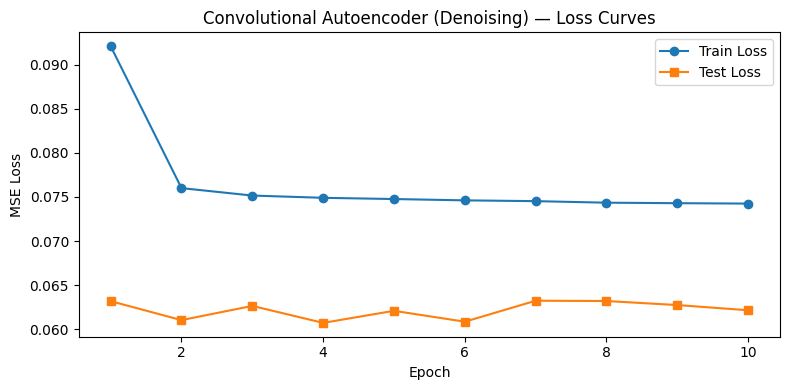

In [32]:
# ===================== YOUR CODE HERE ======================
CAE_DENOISE_Trainer.plot_results()

<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

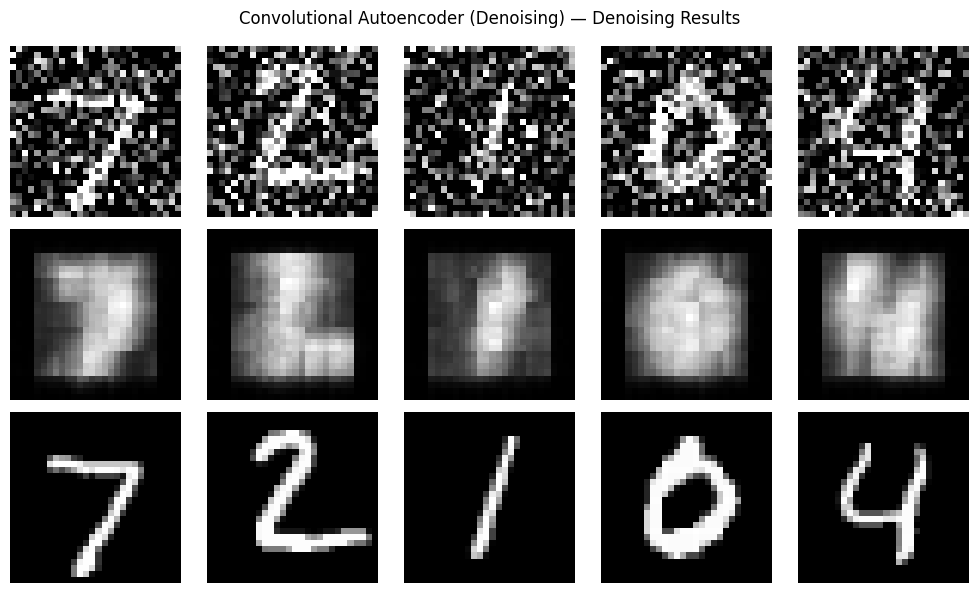

In [33]:
# ===================== YOUR CODE HERE ======================
CAE_DENOISE_Trainer.visualize_denoising(num_images=5)

# ===========================================================
#raise NotImplementedError
# Update Overall_Results dictionary with actual values after training and evaluation
Overall_Results["Task 4"] = {
    "Train Loss (Last Epoch)": CAE_DENOISE_Trainer.train_losses[-1],
    "Test Loss (Last Epoch)":  CAE_DENOISE_Trainer.test_losses[-1],
    "Train Loss (Minimum)":    min(CAE_DENOISE_Trainer.train_losses),
    "Test Loss (Minimum)":     min(CAE_DENOISE_Trainer.test_losses),
}

<hr>

### <h1 style="text-align: left;">Task 4 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 5: Image Classification (Reconstruction) | <span style="color: #9370DB;">CIFAR</span></b></h1>

<hr>

### <h2>1. CIFAR-10 Data Preparation:</h2>

<ul>
    <li><b>Original Data:</b> Use the original CIFAR-10 dataset.</li>
    <li><b>LAE Recon Data:</b> Feed the CIFAR-10 images through the LAE model to obtain the reconstructed images.</li>
    <li><b>CAE Recon Data:</b> Feed the CIFAR-10 images through the CAE model to obtain the reconstructed images.</li>
</ul>

<hr>

<h2>2. Classification Model:</h2>

<p>The task requires training a classifier on the following datasets:</p>
<ul>
    <li><b>Original CIFAR-10:</b> Directly train a classifier on the original CIFAR-10 dataset.</li>
</ul>

<hr>

<h2>3. Evaluation Metrics:</h2>

<p>The following metrics should be used to evaluate and compare the performance of the classifier on each test dataset:</p>

<ul>
    <li><b>Accuracy:</b> Percentage of correct classifications.</li>
    <li><b>Precision:</b> The proportion of positive identifications that were actually correct.</li>
    <li><b>Recall:</b> The proportion of actual positives that were correctly identified.</li>
    <li><b>F1-Score:</b> The harmonic mean of precision and recall, providing a balance between them.</li>
</ul>

<hr>

<h2>4. Comparison:</h2>

<p>For comparison:</p>

<ul>
    <li><b>Accuracy Comparison:</b> Compare the classification accuracy for the original data, LAE recon, and CAE recon.</li>
    <li><b>Confusion Matrices:</b> Plot confusion matrices for each classifier to visualize how the model performs across the different classes.</li>
</ul>

<hr>

<h2>5. Analysis:</h2>

<ul>
    <li><b>Feature Retention:</b> Analyze how well the LAE and CAE models preserve features of the original data during reconstruction.</li>
    <li><b>Impact of Reconstruction:</b> Determine the impact of reconstruction on classification accuracy and model performance.</li>
    <li><b>Best Reconstruction Model:</b> Conclude which reconstruction model (LAE or CAE) preserves the original data's classification features better.</li>
</ul>

<hr>

<h2>6. Visualization:</h2>

<ul>
    <li><b>Plot Metrics:</b> Plot the evaluation metrics (accuracy, precision, recall, F1-score) for each dataset to visualize performance differences.</li>
</ul>

In [34]:
# ================== Create Datasets ==================
LAERecon_dataloader = LAE_RECON_Trainer.create_dataset()
CAERecon_dataloader = CAE_RECON_Trainer.create_dataset()

<hr>

### <h1 style="text-align: left;"> Class | <span style="color: #9370DB;">Convolutional Neural Network Recon</span></h1>

<hr>

In [35]:
class CNNRecon(nn.Module):
    def __init__(self):
        super(CNNRecon, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 32, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 64, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (B, 128, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (B, 128, 4, 4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        x = self.features(x)
        x = self.classifier(x)
        return x

<hr>

### <h1 style="text-align: left;"> Class | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
class CNNClassifierRecon:
    def __init__(self, model, train_loader, test_loader, LAERecon_loader, CAERecon_loader, lr=0.001, num_epochs=20, device=None):
        """
        Initializes the CNN classifier for original and reconstructed datasets.

        Args:
            model (nn.Module): The CNN model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            LAERecon_loader (DataLoader): DataLoader for LAE reconstructed images.
            CAERecon_loader (DataLoader): DataLoader for CAE reconstructed images.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'cuda' or 'cpu', auto-detect if None.
        """
        self.name = "CNN Classifier Reconstruction"
        # ===================== YOUR CODE HERE ======================
        self.model = model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.LAERecon_loader = LAERecon_loader
        self.CAERecon_loader = CAERecon_loader
        self.lr = lr
        self.num_epochs = num_epochs

        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        self.train_losses = []
        self.test_losses = []
        self.train_accuracies = []
        self.test_accuracies = []
    
    def train(self):
        """
        Trains the CNN classifier for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

            epoch_loss = running_loss / len(self.train_loader.dataset)
            epoch_acc = correct / total
            self.train_losses.append(epoch_loss)
            self.train_accuracies.append(epoch_acc)

            test_results = self.evaluate(self.test_loader, print_results=False, epoch=epoch)
            self.test_losses.append(test_results['loss'])
            self.test_accuracies.append(test_results['accuracy'])

            print(f"Epoch [{epoch+1}/{self.num_epochs}]  "
                  f"Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc:.4f}  "
                  f"Test Loss: {test_results['loss']:.4f}  Test Acc: {test_results['accuracy']:.4f}")


    def evaluate(self, dataloader, print_results=True, epoch=None):
        """
        Evaluates the CNN model on a given dataset.

        Args:
            dataloader (DataLoader): The dataset loader to evaluate on.
            print_results (bool): Whether to print evaluation metrics.
            epoch (int or None): Current epoch number if evaluating during training.

        Returns:
            dict: Contains loss, accuracy, precision, recall, f1-score, and confusion matrix.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = running_loss / len(dataloader.dataset)
        accuracy  = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        cm        = confusion_matrix(all_labels, all_preds)

        # Recompute plain accuracy
        accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

        results = {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm
        }

        if print_results:
            label = f"Epoch {epoch+1} | " if epoch is not None else ""
            print(f"\n{label}{dataloader.dataset.__class__.__name__ if hasattr(dataloader.dataset, '__class__') else 'Dataset'} Results:")
            print(f"  Loss:      {avg_loss:.4f}")
            print(f"  Accuracy:  {accuracy:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall:    {recall:.4f}")
            print(f"  F1-Score:  {f1:.4f}")

        return results
    
    def save_model(self, path="CNN_RECON.pth"):
        """
        Saves the trained model to the specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")
    
    def load_model(self, path="CNN_RECON.pth"):
        """
        Loads the trained model from the specified file path.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from {path}")

    def plot_confusion_matrix(self, cm, title):
        cifar10_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=cifar10_classes, yticklabels=cifar10_classes)
        plt.title(title)
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.tight_layout()
        plt.show()

    def plot_metrics(self, original_res, lae_res, cae_res):
        labels = ['Original', 'LAE Recon', 'CAE Recon']
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        titles  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for ax, metric, title in zip(axes, metrics, titles):
            values = [original_res[metric], lae_res[metric], cae_res[metric]]
            bars = ax.bar(labels, values, color=['steelblue', 'tomato', 'seagreen'])
            ax.set_title(title)
            ax.set_ylim(0, 1)
            ax.set_ylabel("Score")
            for bar, val in zip(bars, values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.3f}", ha='center', fontsize=9)
        plt.suptitle("CNN Classifier — Metrics Comparison Across Datasets")
        plt.tight_layout()
        plt.show()

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

In [37]:
CNN_RECON_Model = CNNRecon()
CNN_CLASSIFIER_RECON_Trainer = CNNClassifierRecon(
    model=CNN_RECON_Model,
    train_loader=CIFAR_10_trainloader,
    test_loader=CIFAR_10_testloader,
    LAERecon_loader=LAERecon_dataloader,
    CAERecon_loader=CAERecon_dataloader,
    lr=LEARNING_RATE,
    num_epochs=EPOCHS,
    device=None
)


<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

In [38]:
# ===================== YOUR CODE HERE ======================
CNN_CLASSIFIER_RECON_Trainer.train()

Epoch [1/10]  Train Loss: 1.6184  Train Acc: 0.4056  Test Loss: 1.3193  Test Acc: 0.5158
Epoch [2/10]  Train Loss: 1.2391  Train Acc: 0.5546  Test Loss: 1.0918  Test Acc: 0.6076
Epoch [3/10]  Train Loss: 1.0679  Train Acc: 0.6198  Test Loss: 0.9996  Test Acc: 0.6405
Epoch [4/10]  Train Loss: 0.9412  Train Acc: 0.6663  Test Loss: 0.9220  Test Acc: 0.6741
Epoch [5/10]  Train Loss: 0.8472  Train Acc: 0.7011  Test Loss: 0.8720  Test Acc: 0.6952
Epoch [6/10]  Train Loss: 0.7764  Train Acc: 0.7271  Test Loss: 0.8008  Test Acc: 0.7217
Epoch [7/10]  Train Loss: 0.7139  Train Acc: 0.7495  Test Loss: 0.7925  Test Acc: 0.7230
Epoch [8/10]  Train Loss: 0.6548  Train Acc: 0.7695  Test Loss: 0.7714  Test Acc: 0.7357
Epoch [9/10]  Train Loss: 0.6007  Train Acc: 0.7910  Test Loss: 0.7391  Test Acc: 0.7465
Epoch [10/10]  Train Loss: 0.5512  Train Acc: 0.8059  Test Loss: 0.7478  Test Acc: 0.7478


<hr>

### <h1 style="text-align: left;">Results | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>


Evaluation on Original CIFAR-10

CIFAR10 Results:
  Loss:      0.7478
  Accuracy:  0.7478
  Precision: 0.7477
  Recall:    0.7478
  F1-Score:  0.7441

Evaluation on LAE Reconstructed

TensorDataset Results:
  Loss:      2.9118
  Accuracy:  0.2683
  Precision: 0.4552
  Recall:    0.2683
  F1-Score:  0.2077

=Evaluation on CAE Reconstructed

TensorDataset Results:
  Loss:      1.4431
  Accuracy:  0.5171
  Precision: 0.6024
  Recall:    0.5171
  F1-Score:  0.5202


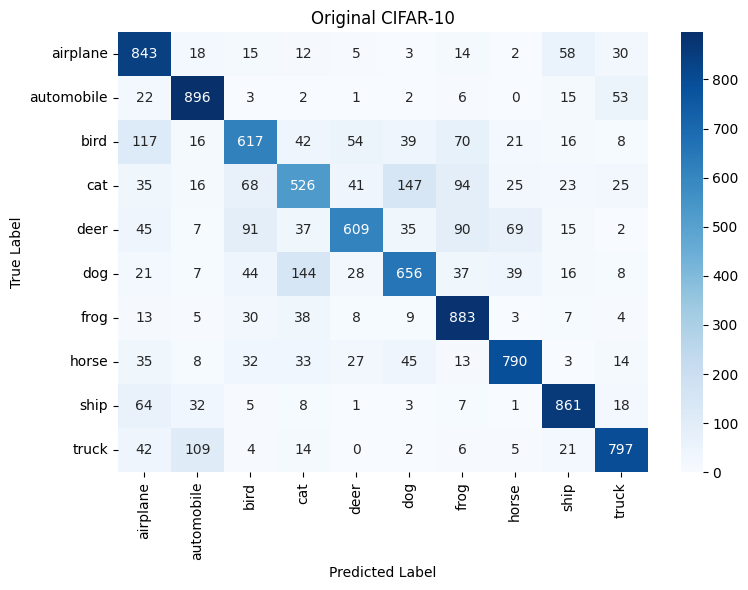

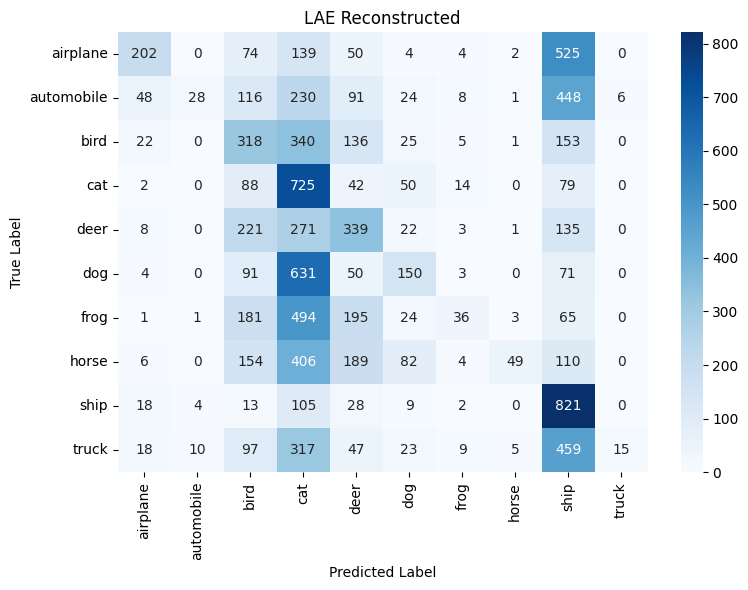

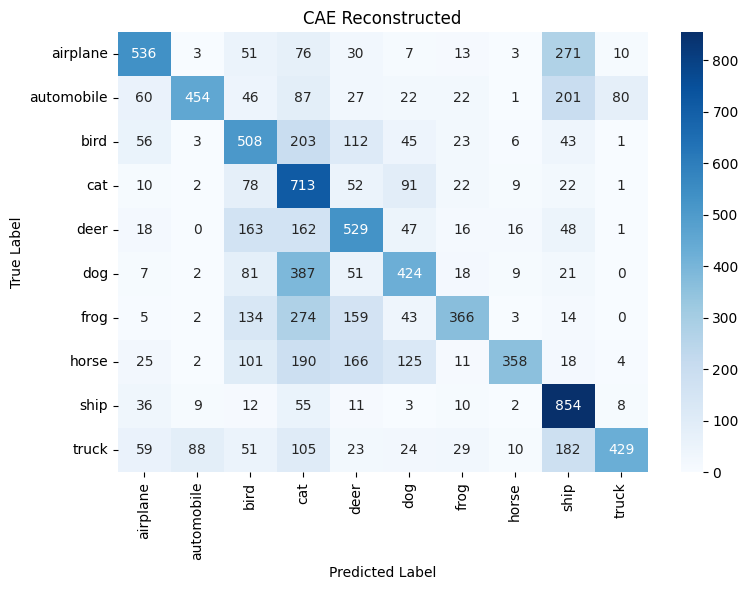

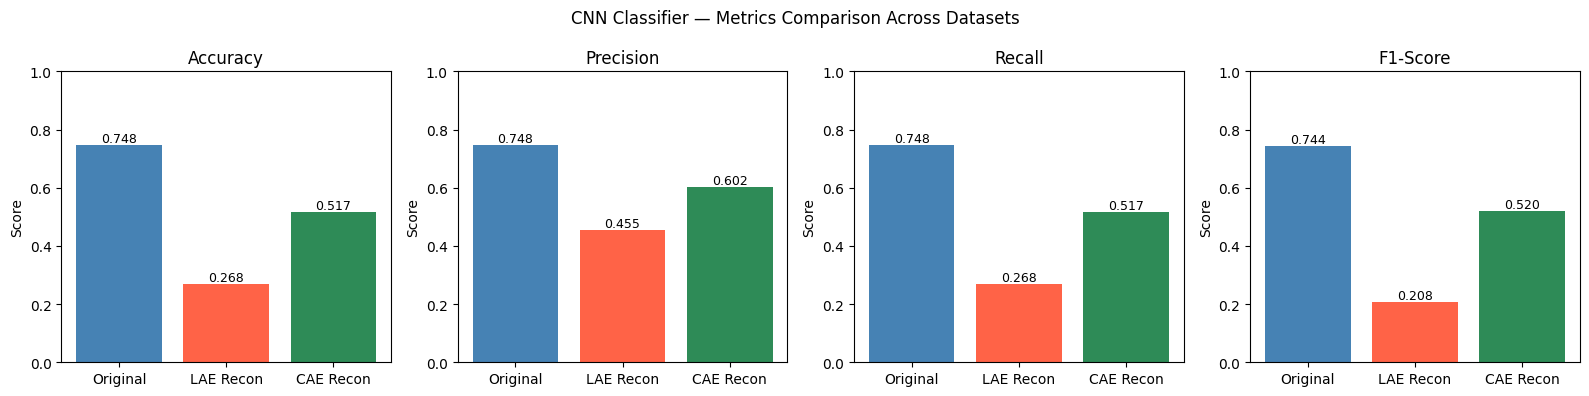

In [39]:
# ===================== YOUR CODE HERE ======================
print("\nEvaluation on Original CIFAR-10")
original_results = CNN_CLASSIFIER_RECON_Trainer.evaluate(CIFAR_10_testloader, print_results=True)

print("\nEvaluation on LAE Reconstructed")
lae_results = CNN_CLASSIFIER_RECON_Trainer.evaluate(LAERecon_dataloader, print_results=True)

print("\n=Evaluation on CAE Reconstructed")
cae_results = CNN_CLASSIFIER_RECON_Trainer.evaluate(CAERecon_dataloader, print_results=True)

CNN_CLASSIFIER_RECON_Trainer.plot_confusion_matrix(original_results['confusion_matrix'], "Original CIFAR-10")
CNN_CLASSIFIER_RECON_Trainer.plot_confusion_matrix(lae_results['confusion_matrix'],      "LAE Reconstructed")
CNN_CLASSIFIER_RECON_Trainer.plot_confusion_matrix(cae_results['confusion_matrix'],      "CAE Reconstructed")

CNN_CLASSIFIER_RECON_Trainer.plot_metrics(original_results, lae_results, cae_results)
        
# Update Overall_Results dictionary with actual values after training and evaluation
Overall_Results["Task 5"] = {
    "Train Loss (Last Epoch)":      CNN_CLASSIFIER_RECON_Trainer.train_losses[-1],
    "Test Loss (Last Epoch)":       CNN_CLASSIFIER_RECON_Trainer.test_losses[-1],
    "Train Accuracy (Last Epoch)":  CNN_CLASSIFIER_RECON_Trainer.train_accuracies[-1],
    "Test Accuracy (Last Epoch)":   CNN_CLASSIFIER_RECON_Trainer.test_accuracies[-1],
    "Train Loss (Minimum)":         min(CNN_CLASSIFIER_RECON_Trainer.train_losses),
    "Test Loss (Minimum)":          min(CNN_CLASSIFIER_RECON_Trainer.test_losses),
    "Train Accuracy (Maximum)":     max(CNN_CLASSIFIER_RECON_Trainer.train_accuracies),
    "Test Accuracy (Maximum)":      max(CNN_CLASSIFIER_RECON_Trainer.test_accuracies),
}

<hr>

### <h1 style="text-align: left;">Analysis | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

**Answer here:**
CNN achieves strong performance on the original CIFAR-10 dataset, ≈75% accuracy, but performance drops significantly on reconstructed images. With the LAE reconstruction, accuracy falls to 27%, and the confusion matrix shows severe mixing across visually similar classes such as airplane-ship and cat-dog-deer. This occurs because the fully connected bottleneck destroys spatial structure, removing edge information and local textures that CNNs rely on for feature extraction. Although global color patterns may remain, discriminative spatial cues are largely lost.

CAE performs better, ≈49% accuracy, because it preserves spatial locality through convolutional layers. Its confusion matrix shows a stronger diagonal, particularly for structurally distinct classes like ships and trucks. However, blurring and loss of fine details still reduce class separability, especially among similar animal classes. Overall, the results show that preserving spatial structure is critical for maintaining discriminative features in downstream classification tasks.
<hr>

<hr>

### <h1 style="text-align: left;">Task 5 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 6: Image Classification (Denoising) | <span style="color: #9370DB;">MNIST</span></b></h1>

<hr>

### <h2>1. MNIST Data Preparation:</h2>

<ul>
    <li><b>Original Data:</b> Use the original MNIST dataset.</li>
    <li><b>LAE Denoised Data:</b> Pass the noisy MNIST images through the LAE model to obtain the denoised images.</li>
    <li><b>CAE Denoised Data:</b> Pass the noisy MNIST images through the CAE model to obtain the denoised images.</li>
</ul>

<hr>

<h2>2. Classification Model:</h2>

<p>The task requires training a classifier on the following datasets:</p>
<ul>
    <li><b>Original MNIST:</b> Train a classifier on the original MNIST dataset.</li>
</ul>

<hr>

<h2>3. Evaluation Metrics:</h2>

<p>The following metrics should be used to evaluate and compare the performance of the classifier on each test dataset:</p>

<ul>
    <li><b>Accuracy:</b> Percentage of correct classifications.</li>
    <li><b>Precision:</b> The proportion of positive identifications that were actually correct.</li>
    <li><b>Recall:</b> The proportion of actual positives that were correctly identified.</li>
    <li><b>F1-Score:</b> The harmonic mean of precision and recall, providing a balance between them.</li>
</ul>

<hr>

<h2>4. Comparison:</h2>

<p>For comparison:</p>

<ul>
    <li><b>Accuracy Comparison:</b> Compare the classification accuracy for the original data, LAE denoised, and CAE denoised images.</li>
    <li><b>Confusion Matrices:</b> Plot confusion matrices for each classifier to visualize how the model performs across different classes.</li>
</ul>

<hr>

<h2>5. Analysis:</h2>

<ul>
    <li><b>Noise Reduction Effectiveness:</b> Analyze how well the LAE and CAE models remove noise while retaining key features.</li>
    <li><b>Impact of Denoising:</b> Determine the impact of denoising on classification accuracy and model performance.</li>
    <li><b>Best Denoising Model:</b> Conclude which denoising model (LAE or CAE) preserves the original data's classification features better.</li>
</ul>

<hr>

<h2>6. Visualization:</h2>

<ul>
    <li><b>Plot Metrics:</b> Plot the evaluation metrics (accuracy, precision, recall, F1-score) for each dataset to visualize performance differences.</li>
</ul>


In [40]:
# ================== Create Datasets ==================
LAEDenoise_dataloader = LAE_DENOISE_Trainer.create_dataset()
CAEDenoise_dataloader = CAE_DENOISE_Trainer.create_dataset()

<hr>

### <h1 style="text-align: left;"> Class | <span style="color: #9370DB;">Convolutional Neural Network Denoising</span></h1>

<hr>

In [41]:
class CNNDenoise(nn.Module):
    def __init__(self):
        super(CNNDenoise, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (B, 32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (B, 64, 7, 7)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        x = self.features(x)
        x = self.classifier(x)
        return x

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

In [42]:
class CNNClassifierDenoise:
    def __init__(self, model, train_loader, test_loader, LAEDenoise_loader, CAEDenoise_loader, lr=0.001, num_epochs=20, device=None):
        """
        Initializes the CNN classifier for original and denoised datasets.

        Args:
            model (nn.Module): The CNN model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            LAEDenoise_loader (DataLoader): DataLoader for LAE denoised images.
            CAEDenoise_loader (DataLoader): DataLoader for CAE denoised images.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'cuda' or 'cpu', auto-detect if None.
        """
        self.name = "CNN Classifier Denoising"
        # ===================== YOUR CODE HERE ======================
        self.model = model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.LAEDenoise_loader = LAEDenoise_loader
        self.CAEDenoise_loader = CAEDenoise_loader
        self.lr = lr
        self.num_epochs = num_epochs

        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        self.train_losses = []
        self.test_losses = []
        self.train_accuracies = []
        self.test_accuracies = []
    
    def train(self):
        """
        Trains the CNN classifier for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

            epoch_loss = running_loss / len(self.train_loader.dataset)
            epoch_acc = correct / total
            self.train_losses.append(epoch_loss)
            self.train_accuracies.append(epoch_acc)

            test_results = self.evaluate(self.test_loader, print_results=False, epoch=epoch)
            self.test_losses.append(test_results['loss'])
            self.test_accuracies.append(test_results['accuracy'])

            print(f"Epoch [{epoch+1}/{self.num_epochs}]  "
                  f"Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc:.4f}  "
                  f"Test Loss: {test_results['loss']:.4f}  Test Acc: {test_results['accuracy']:.4f}")

    
    def evaluate(self, dataloader, print_results=True, epoch=None):
        """
        Evaluates the CNN model on a given dataset.

        Args:
            dataloader (DataLoader): The dataset loader to evaluate on.
            print_results (bool): Whether to print evaluation metrics.
            epoch (int or None): Current epoch number if evaluating during training.

        Returns:
            dict: Contains loss, accuracy, precision, recall, f1-score, and confusion matrix.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = running_loss / len(dataloader.dataset)
        accuracy  = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        cm        = confusion_matrix(all_labels, all_preds)

        results = {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm
        }

        if print_results:
            label = f"Epoch {epoch+1} | " if epoch is not None else ""
            print(f"\n{label}Results:")
            print(f"  Loss:      {avg_loss:.4f}")
            print(f"  Accuracy:  {accuracy:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall:    {recall:.4f}")
            print(f"  F1-Score:  {f1:.4f}")

        return results
    
    def save_model(self, path="CNN_Denoise.pth"):
        """
        Saves the trained model to the specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")
    
    def load_model(self, path="CNN_Denoise.pth"):
        """
        Loads the trained model from the specified file path.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from {path}")

    def plot_confusion_matrix(self, cm, title):
        mnist_classes = [str(i) for i in range(10)]
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=mnist_classes, yticklabels=mnist_classes)
        plt.title(title)
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.tight_layout()
        plt.show()

    def plot_metrics(self, original_res, lae_res, cae_res):
        labels  = ['Original', 'LAE Denoised', 'CAE Denoised']
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        titles  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for ax, metric, title in zip(axes, metrics, titles):
            values = [original_res[metric], lae_res[metric], cae_res[metric]]
            bars = ax.bar(labels, values, color=['steelblue', 'tomato', 'seagreen'])
            ax.set_title(title)
            ax.set_ylim(0, 1)
            ax.set_ylabel("Score")
            for bar, val in zip(bars, values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.3f}", ha='center', fontsize=9)
        plt.suptitle("CNN Classifier — Metrics Comparison Across Denoised Datasets")
        plt.tight_layout()
        plt.show()

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

In [43]:
CNN_DENOISE_Model = CNNDenoise()
CNN_CLASSIFIER_DENOISE_Trainer = CNNClassifierDenoise(
    model=CNN_DENOISE_Model,
    train_loader=MNIST_trainloader,
    test_loader=MNIST_testloader,
    LAEDenoise_loader=LAEDenoise_dataloader,
    CAEDenoise_loader=CAEDenoise_dataloader,
    lr=LEARNING_RATE,
    num_epochs=EPOCHS,
    device=None
)

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

In [44]:
# ===================== YOUR CODE HERE ======================
CNN_CLASSIFIER_DENOISE_Trainer.train()

Epoch [1/10]  Train Loss: 0.2443  Train Acc: 0.9255  Test Loss: 0.0505  Test Acc: 0.9838
Epoch [2/10]  Train Loss: 0.0630  Train Acc: 0.9809  Test Loss: 0.0356  Test Acc: 0.9888
Epoch [3/10]  Train Loss: 0.0455  Train Acc: 0.9863  Test Loss: 0.0312  Test Acc: 0.9899
Epoch [4/10]  Train Loss: 0.0356  Train Acc: 0.9891  Test Loss: 0.0302  Test Acc: 0.9896
Epoch [5/10]  Train Loss: 0.0290  Train Acc: 0.9906  Test Loss: 0.0252  Test Acc: 0.9913
Epoch [6/10]  Train Loss: 0.0252  Train Acc: 0.9921  Test Loss: 0.0260  Test Acc: 0.9914
Epoch [7/10]  Train Loss: 0.0206  Train Acc: 0.9935  Test Loss: 0.0229  Test Acc: 0.9929
Epoch [8/10]  Train Loss: 0.0177  Train Acc: 0.9942  Test Loss: 0.0229  Test Acc: 0.9929
Epoch [9/10]  Train Loss: 0.0161  Train Acc: 0.9948  Test Loss: 0.0304  Test Acc: 0.9899
Epoch [10/10]  Train Loss: 0.0150  Train Acc: 0.9949  Test Loss: 0.0254  Test Acc: 0.9914


<hr>

### <h1 style="text-align: left;">Results | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>


Evaluation on Original MNIST

Results:
  Loss:      0.0254
  Accuracy:  0.9914
  Precision: 0.9913
  Recall:    0.9914
  F1-Score:  0.9914

Evaluation on LAE Denoised

Results:
  Loss:      2.3728
  Accuracy:  0.1031
  Precision: 0.0104
  Recall:    0.0999
  F1-Score:  0.0189

Evaluation on CAE Denoised

Results:
  Loss:      2.0733
  Accuracy:  0.2657
  Precision: 0.4269
  Recall:    0.2568
  F1-Score:  0.1951


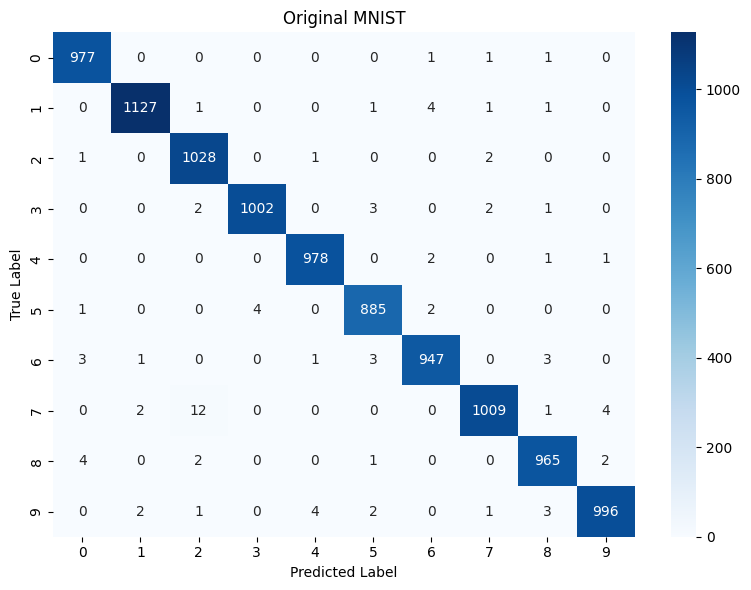

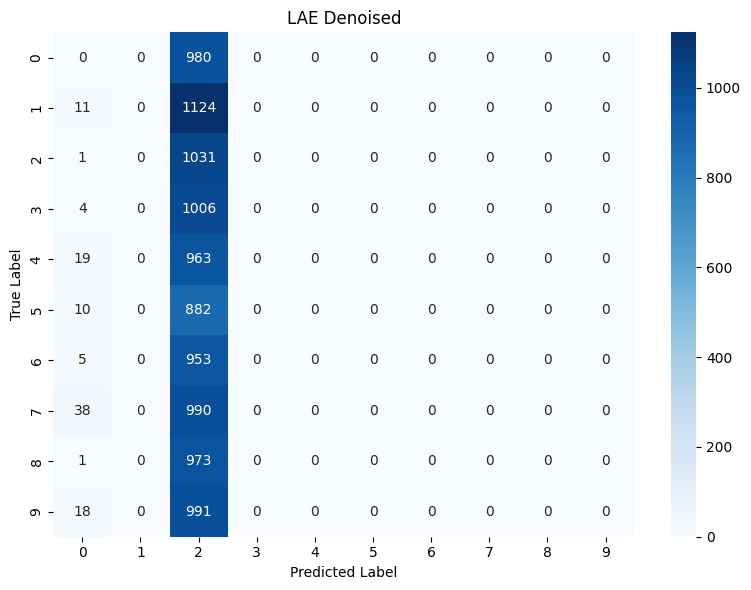

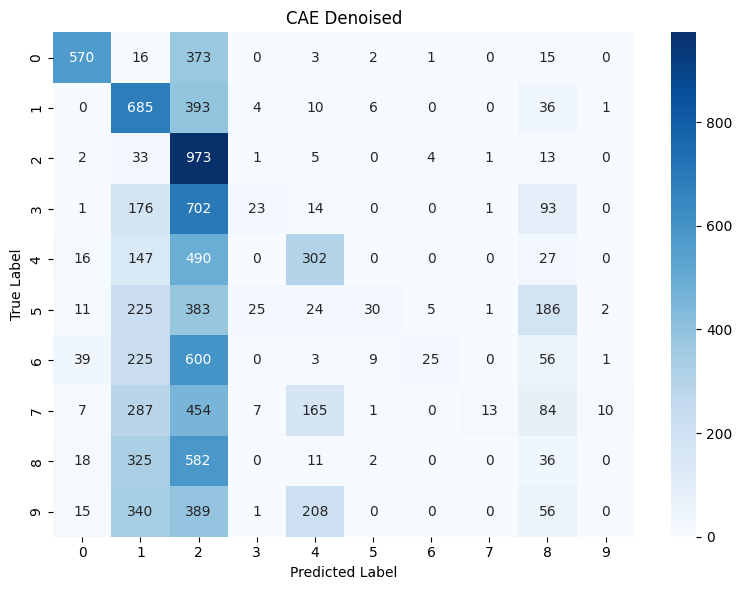

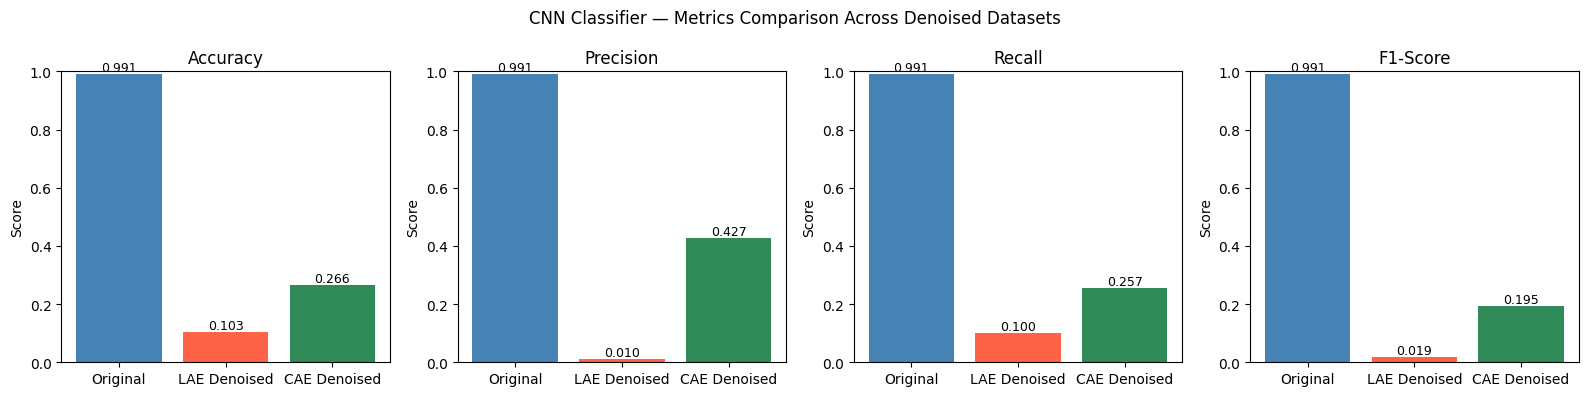

In [45]:
# ===================== YOUR CODE HERE ======================
print("\nEvaluation on Original MNIST")
original_results = CNN_CLASSIFIER_DENOISE_Trainer.evaluate(MNIST_testloader, print_results=True)

print("\nEvaluation on LAE Denoised")
lae_results = CNN_CLASSIFIER_DENOISE_Trainer.evaluate(LAEDenoise_dataloader, print_results=True)

print("\nEvaluation on CAE Denoised")
cae_results = CNN_CLASSIFIER_DENOISE_Trainer.evaluate(CAEDenoise_dataloader, print_results=True)

CNN_CLASSIFIER_DENOISE_Trainer.plot_confusion_matrix(original_results['confusion_matrix'], "Original MNIST")
CNN_CLASSIFIER_DENOISE_Trainer.plot_confusion_matrix(lae_results['confusion_matrix'],      "LAE Denoised")
CNN_CLASSIFIER_DENOISE_Trainer.plot_confusion_matrix(cae_results['confusion_matrix'],      "CAE Denoised")
CNN_CLASSIFIER_DENOISE_Trainer.plot_metrics(original_results, lae_results, cae_results)

# Update Overall_Results dictionary with actual values after training and evaluation
Overall_Results["Task 6"] = {
    "Train Loss (Last Epoch)": None,
    "Test Loss (Last Epoch)": None,
    "Train Accuracy (Last Epoch)": None,
    "Test Accuracy (Last Epoch)": None,
    "Train Loss (Minimum)": None,
    "Test Loss (Minimum)": None,
    "Train Accuracy (Maximum)": None,
    "Test Accuracy (Maximum)": None,
}

<hr>

### <h1 style="text-align: left;">Analysis | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

**Answer here:**
The CNN achieves near-perfect performance on the original MNIST dataset, ≈99.2% accuracy, with a clean confusion matrix showing an almost perfectly dominant diagonal. However, performance collapses when evaluated on LAE denoised images, dropping to 10% accuracy, essentially random guessing. The confusion matrix shows that nearly all samples are predicted as a single class i.e., digit 3, indicating that the linear autoencoder severely distorts digit structure. Because LAE uses a fully connected bottleneck, it destroys spatial relationships and stroke continuity, which are critical for digit recognition.

CAE denoised images perform better, ≈33% accuracy, as convolutional layers preserve spatial locality and stroke patterns. The confusion matrix shows partial recovery of diagonal structure, but heavy mixing remains among similar digits e.g., 3–5, 4–9, 1–7. Blurring and smoothing during reconstruction reduce fine stroke distinctions, making structurally similar digits harder to separate. The results confirm that preserving spatial structure through convolutional inductive bias is essential for maintaining class-discriminative features in denoising tasks.
<hr>

<hr>

### <h1 style="text-align: left;">Task 6 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 7: Classification using Latent Space | <span style="color: #9370DB;">CIFAR-10</span></b></h1>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Convolutional AutoEncoder</span></h1>

<hr>

In [46]:
class ConvolutionalAutoencoderLatentSpace(nn.Module):
    def __init__(self):
        super(ConvolutionalAutoencoderLatentSpace, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),    # (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                             # (B, 32, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # (B, 64, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                             # (B, 64, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # (B, 128, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                              # (B, 128, 4, 4)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # (B, 64, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),   # (B, 32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),    # (B, 3, 32, 32)
            nn.Sigmoid()
        )

    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        z = self.encoder(x)
        x = self.decoder(z)
        return x

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Trainer + Interpolation</span></h1>

<hr>

### <h2>Interpolation in Latent Space</h2>

<p>Interpolation in an autoencoder's latent space involves generating intermediate representations between two encoded data points. 
In the <code>AutoencoderTrainer</code> class, this is implemented through two methods:</p>

<ul>
    <li><b><code>interpolate_same_class</code></b>: Performs interpolation between two samples of the same class.</li>
    <li><b><code>interpolate_different_classes</code></b>: Interpolates between two samples belonging to different classes.</li>
</ul>

<hr>

<h2>Why Do We Perform Interpolation?</h2>

<ul>
    <li>
        <b>Understanding the Learned Latent Space</b>
        <ul>
            <li>By interpolating between encoded representations, we can analyze how the model organizes and encodes data.</li>
            <li>A well-trained autoencoder should produce smooth transitions between interpolated samples.</li>
        </ul>
    </li>
    <li>
        <b>Semantic Meaning of Latent Representations</b>
        <ul>
            <li>If interpolation results in meaningful intermediate samples, it suggests that the latent space is structured logically.</li>
            <li>For same-class interpolation, a gradual shift should preserve key features of the class.</li>
            <li>For different-class interpolation, the transition should indicate how the model bridges the gap between distinct classes.</li>
        </ul>
    </li>
    <li>
        <b>Evaluating the Decoder</b>
        <ul>
            <li>The reconstructed interpolated samples help determine whether the decoder can generalize well beyond just memorizing training samples.</li>
        </ul>
    </li>
</ul>

<hr>

<h2>How the <code>AutoencoderTrainer</code> Class Implements Interpolation</h2>

<p>In the provided implementation:</p>

<ul>
    <li>The <b>encoder</b> compresses input images into a latent representation.</li>
    <li>Two latent vectors are selected based on class labels.</li>
    <li>Intermediate points are computed using weighted combinations of the two latent vectors.</li>
    <li>The <b>decoder</b> reconstructs images from the interpolated latent representations.</li>
    <li>The function <code>visualize_interpolation</code> helps in analyzing how interpolation affects the generated samples.</li>
</ul>

<p>By running these interpolation methods, one can visually inspect whether the autoencoder has learned a meaningful latent space.</p>

In [47]:
class AutoencoderTrainer:
    """
    A class to train an autoencoder model and perform latent space interpolations.
    This trainer supports training, latent space interpolations between
    same and different class samples, visualization, and model saving/loading.
    """
    
    def __init__(self, model, device="cuda" if torch.cuda.is_available() else "cpu"):
        """
        Initializes the AutoencoderTrainer.

        Args:
            model: The autoencoder model to be trained and evaluated.
            device: The device to run computations on ("cuda" or "cpu").
        """
        # ===================== YOUR CODE HERE ======================
        self.model = model
        self.device = torch.device(device)
        self.model.to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        self.train_losses = []
    
    def train(self, train_loader, epochs=10):
        """
        Trains the autoencoder model using mean squared error loss.

        Args:
            train_loader: DataLoader for training dataset.
            epochs: Number of training epochs (default is 10).
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(epochs):
            self.model.train()
            running_loss = 0.0

            for images, _ in train_loader:
                images = images.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, images)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * images.size(0)

            epoch_loss = running_loss / len(train_loader.dataset)
            self.train_losses.append(epoch_loss)
            print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.6f}")
    
    def interpolate_same_class(self, dataloader, steps=10):
        """
        Performs latent space interpolation between two images of the same class.

        Args:
            dataloader: DataLoader containing the dataset.
            steps: Number of interpolation steps (default is 10).

        Returns:
            A tensor containing interpolated images if successful, else None.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()

        # Collect images by class
        class_images = {}
        with torch.no_grad():
            for images, labels in dataloader:
                for img, label in zip(images, labels):
                    l = label.item()
                    if l not in class_images:
                        class_images[l] = []
                    if len(class_images[l]) < 2:
                        class_images[l].append(img)
                # Stop once we have 2 samples for at least one class
                if any(len(v) >= 2 for v in class_images.values()):
                    break

        # Pick first class with 2 samples
        target_class = next(k for k, v in class_images.items() if len(v) >= 2)
        img1, img2 = class_images[target_class][0], class_images[target_class][1]

        img1_t = img1.unsqueeze(0).to(self.device)
        img2_t = img2.unsqueeze(0).to(self.device)

        with torch.no_grad():
            z1 = self.model.encoder(img1_t)
            z2 = self.model.encoder(img2_t)

            interpolated = []
            for alpha in torch.linspace(0, 1, steps):
                z_interp = (1 - alpha) * z1 + alpha * z2
                decoded = self.model.decoder(z_interp)
                interpolated.append(decoded.squeeze(0).cpu())

        self.visualize_interpolation(img1, img2, interpolated,
                                     title=f"Same Class Interpolation (Class {target_class})")
        return torch.stack(interpolated)


    def interpolate_different_classes(self, dataloader, steps=10):
        """
        Performs latent space interpolation between two images of different classes.

        Args:
            dataloader: DataLoader containing the dataset.
            steps: Number of interpolation steps (default is 10).

        Returns:
            A tensor containing interpolated images if successful, else None.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()

        # Collect one image per class
        class_images = {}
        with torch.no_grad():
            for images, labels in dataloader:
                for img, label in zip(images, labels):
                    l = label.item()
                    if l not in class_images:
                        class_images[l] = img
                if len(class_images) >= 2:
                    break

        classes = list(class_images.keys())[:2]
        img1, img2 = class_images[classes[0]], class_images[classes[1]]

        img1_t = img1.unsqueeze(0).to(self.device)
        img2_t = img2.unsqueeze(0).to(self.device)

        with torch.no_grad():
            z1 = self.model.encoder(img1_t)
            z2 = self.model.encoder(img2_t)

            interpolated = []
            for alpha in torch.linspace(0, 1, steps):
                z_interp = (1 - alpha) * z1 + alpha * z2
                decoded = self.model.decoder(z_interp)
                interpolated.append(decoded.squeeze(0).cpu())

        self.visualize_interpolation(img1, img2, interpolated,
                                     title=f"Different Class Interpolation (Class {classes[0]} → Class {classes[1]})")
        return torch.stack(interpolated)

    def visualize_interpolation(self, img1, img2, interpolated_images, title):
        """
        Visualizes interpolation results between two images.

        Args:
            img1: First image.
            img2: Second image.
            interpolated_images: List of interpolated images.
            title: Title for the visualization.
        """
        # ===================== YOUR CODE HERE ======================
        all_images = [img1] + interpolated_images + [img2]
        n = len(all_images)

        fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2.5))
        for i, (ax, img) in enumerate(zip(axes, all_images)):
            img_np = img.permute(1, 2, 0).numpy().clip(0, 1)
            if img_np.shape[2] == 1:
                ax.imshow(img_np.squeeze(), cmap='gray')
            else:
                ax.imshow(img_np)
            ax.axis('off')
            if i == 0:
                ax.set_title("Start", fontsize=7)
            elif i == n - 1:
                ax.set_title("End", fontsize=7)
            else:
                ax.set_title(f"α={i/(n-1):.1f}", fontsize=7)

        plt.suptitle(title, fontsize=10)
        plt.tight_layout()
        plt.show()
        
    def save_model(self, path="/models/CAE_LATENT_SPACE.pth"):
        """
        Saves the model state to the specified file.

        Args:
            path: File path where the model will be saved.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

    def load_model(self, path="/models/CAE_LATENT_SPACE.pth"):
        """
        Loads the model state from the specified file.

        Args:
            path: File path from where the model will be loaded.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from {path}")

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CAE Latent Space</span></h1>

<hr>

In [48]:
CAE_LATENT_SPACE_Model = ConvolutionalAutoencoderLatentSpace()
CAE_LATENT_SPACE_Trainer = AutoencoderTrainer(
    model=CAE_LATENT_SPACE_Model,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CAE Latent Space</span></h1>

<hr>

In [49]:
# ===================== YOUR CODE HERE ======================
CAE_LATENT_SPACE_Trainer.train(train_loader=CIFAR_10_trainloader, epochs=EPOCHS)

Epoch [1/10]  Loss: 0.020935
Epoch [2/10]  Loss: 0.010604
Epoch [3/10]  Loss: 0.009243
Epoch [4/10]  Loss: 0.008430
Epoch [5/10]  Loss: 0.007896
Epoch [6/10]  Loss: 0.007455
Epoch [7/10]  Loss: 0.006895
Epoch [8/10]  Loss: 0.006531
Epoch [9/10]  Loss: 0.006308
Epoch [10/10]  Loss: 0.006120


<hr>

### <h1 style="text-align: left;">Interpolation | <span style="color: #9370DB;">CAE Latent Space</span></h1>

<hr>

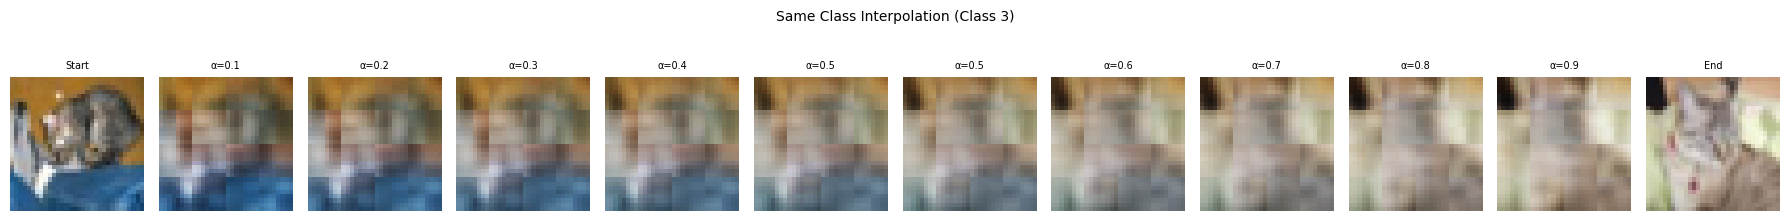

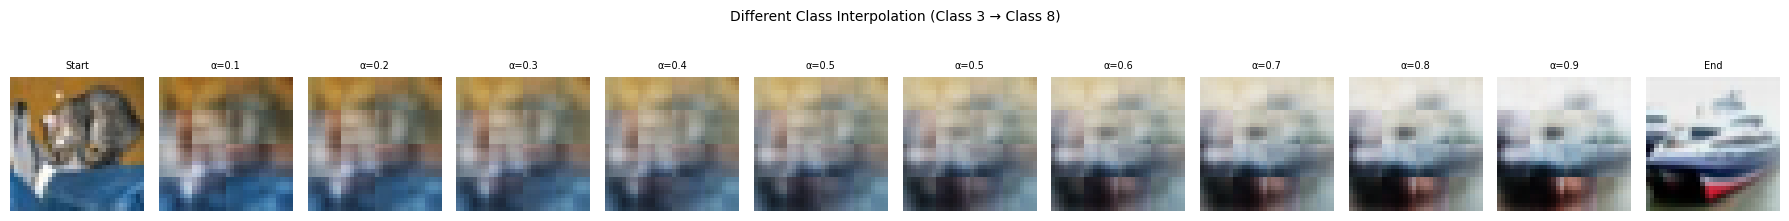

In [50]:
# Same class interpolation
same_class_imgs = CAE_LATENT_SPACE_Trainer.interpolate_same_class(
    dataloader=CIFAR_10_testloader,
    steps=10
)

# Different class interpolation
diff_class_imgs = CAE_LATENT_SPACE_Trainer.interpolate_different_classes(
    dataloader=CIFAR_10_testloader,
    steps=10
)

<hr>

### <h1 style="text-align: left;">Task 7 | <span style="color: #9370DB;">End</span></h1>

<hr>

In [51]:
Overall_Results["Task 6"] = {
    "Train Loss (Last Epoch)": CAE_LATENT_SPACE_Trainer.train_losses[-1],
    "Test Loss (Last Epoch)":  None,  # not applicable — unsupervised
    "Train Loss (Minimum)":    min(CAE_LATENT_SPACE_Trainer.train_losses),
    "Test Loss (Minimum)":     None,  # not applicable — unsupervised
}

print(Overall_Results["Task 6"])

{'Train Loss (Last Epoch)': 0.006119767558127642, 'Test Loss (Last Epoch)': None, 'Train Loss (Minimum)': 0.006119767558127642, 'Test Loss (Minimum)': None}


<hr>

### <h1 style="text-align: left;"> Save Results | <span style="color: #9370DB;">Update JSON</span></h1>

<hr>

In [52]:
import json

print(json.dumps(Overall_Results, indent=4))

# overwrite same file with final results
with open(RESULTS_FILE, 'w') as f:
    json.dump(Overall_Results, f, indent=4)

print("Final JSON saved:", RESULTS_FILE)


{
    "Task 1": {
        "Train Loss (Last Epoch)": 0.013322933047711849,
        "Test Loss (Last Epoch)": 0.013320234650373458,
        "Train Loss (Minimum)": 0.013322933047711849,
        "Test Loss (Minimum)": 0.013320234650373458
    },
    "Task 2": {
        "Train Loss (Last Epoch)": 0.0061699043987691405,
        "Test Loss (Last Epoch)": 0.006200988112390041,
        "Train Loss (Minimum)": 0.0061699043987691405,
        "Test Loss (Minimum)": 0.006200988112390041
    },
    "Task 3": {
        "Train Loss (Last Epoch)": 0.06729739845991134,
        "Test Loss (Last Epoch)": 0.06751444106101989,
        "Train Loss (Minimum)": 0.06729475135008495,
        "Test Loss (Minimum)": 0.06743823238611221
    },
    "Task 4": {
        "Train Loss (Last Epoch)": 0.07424984963734944,
        "Test Loss (Last Epoch)": 0.06215356427431107,
        "Train Loss (Minimum)": 0.07424984963734944,
        "Test Loss (Minimum)": 0.06072165586948395
    },
    "Task 5": {
        "Train Loss 

In [55]:
!ls
from google.colab import files
files.download("26100337_Overall_Results.json")

26100337_Overall_Results.json  data  sample_data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<hr>

### <h1 style="text-align: center;">THE END</h1>

<hr>